In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import math
import pandas as pd
from collections import defaultdict
import gzip
import math

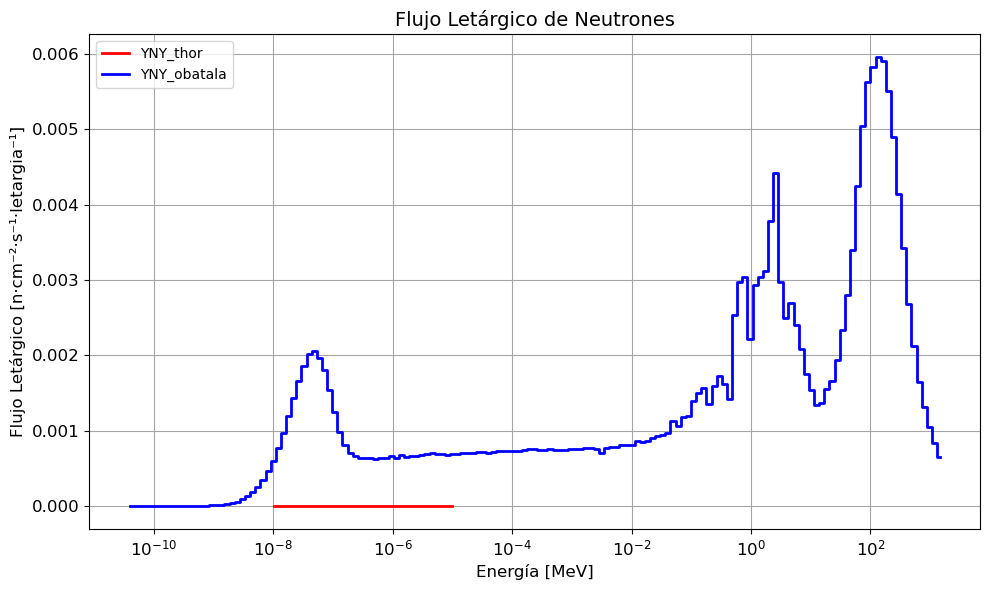

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Definir área de detección (cm²) y tiempos de integración (s)
A = (40000)**2  # Área en cm²
time_default = 12 * 3600 / (400**2)  # Tiempo por defecto en segundos
time_mcg = (1/4) * 3600 / (400**2)  # Tiempo específico para (1 hora en segundos, ajusta según necesites)

# Lista de archivos de entrada y sus tiempos correspondientes
input_file1 = "filtered_neutrons.shw"
input_file2 = "all_bga_neutron_35.shw"
files = [input_file1, input_file2]
times = [time_default, time_mcg]  # Lista de tiempos para cada archivo
labels = ["YNY_thor", "YNY_obatala"]

# Función para procesar los archivos y graficar solo el flujo letárgico
def neutron_flux(files, times, output_pdf_name, A):
    """
    Procesa múltiples archivos de flujos de neutrones y grafica solo el flujo letárgico.
    
    :param files: Lista de archivos de entrada.
    :param times: Lista de tiempos de integración (s) para cada archivo.
    :param output_pdf_name: Nombre del archivo de salida para la gráfica.
    :param A: Área de detección (cm²).
    """
    m = 939.6  # Masa del neutrón en MeV/c^2
    plt.figure(figsize=(10, 6))  # Crear figura
    colors = ['r', 'b', 'g', 'm', 'c', 'y', 'k']  # Colores para diferenciar curvas
    
    for i, file in enumerate(files):
        # Usar el tiempo correspondiente a este archivo
        time = times[i]
        
        # Leer el archivo CSV con formato adecuado
        df = pd.read_csv(file, delimiter=" ", skiprows=1, skipinitialspace=True, comment="#", on_bad_lines='skip')
        df.columns = ["particle", "px", "py", "pz", "x", "y", "z", "shower_id", "prm_id", "prm_energy", "prm_theta", "prm_phi"]
        
        # Filtrar solo los neutrones
        df_neutrons = df[df["particle"] == "neutron"].copy()
        
        # Calcular la energía cinética (Ek) usando la fórmula Ek = (p² / 2m)
        df_neutrons["Ek"] = (df_neutrons["px"]**2 + df_neutrons["py"]**2 + df_neutrons["pz"]**2) / (2 * m)
        
        # Filtrar energías válidas (Ek < 1573 MeV y Ek != 0)
        df_neutrons = df_neutrons[(df_neutrons["Ek"] < 1573.0) & (df_neutrons["Ek"] != 0)]
        neu_Ek = np.array(df_neutrons["Ek"])
        
        # Definir bins logarítmicos para energía
        min_Ek, max_Ek = np.min(neu_Ek), np.max(neu_Ek)
        num_bins = 159
        bins_Ek = np.logspace(np.log10(min_Ek), np.log10(max_Ek), num_bins + 1)
        
        # Calcular histograma de energía cinética
        y_diff, _ = np.histogram(neu_Ek, bins=bins_Ek, density=False)
        bin_centers = (bins_Ek[1:] + bins_Ek[:-1]) / 2  # Centros de los bins
        bin_widths = bins_Ek[1:] - bins_Ek[:-1]  # Ancho de los bins
        
        # Calcular flujo diferencial
        phi_diff = y_diff / (A * time * bin_centers)
        
        # Calcular flujo letárgico: φ_lethargy(u) = φ_diff(E) * E_mid
        phi_lethargy = phi_diff * bin_centers
        
        # Graficar flujo letárgico
        color = colors[i % len(colors)]  # Ciclar colores si hay más archivos
        plt.step(bin_centers, phi_lethargy, color=color, where='mid', label=f'{labels[i]}', linewidth=2)
    
    # Configuración de la gráfica
    plt.xscale('log')  # Escala logarítmica en el eje X
    plt.xlabel('Energía [MeV]', size=12)
    plt.ylabel('Flujo Letárgico [n·cm⁻²·s⁻¹·letargia⁻¹]', size=12)
    plt.title('Flujo Letárgico de Neutrones', size=14)
    plt.grid(True, which="both", ls="-", color='0.65')
    plt.legend()
    plt.tick_params(labelsize=12)
    
    # Guardar la gráfica en un archivo
    plt.tight_layout()
    plt.savefig(output_pdf_name)
    plt.show()

# Ejecutar la función con los archivos y tiempos especificados
output_name = "flux_neutrons_combined_2.png"
neutron_flux(files, times, output_name, A)


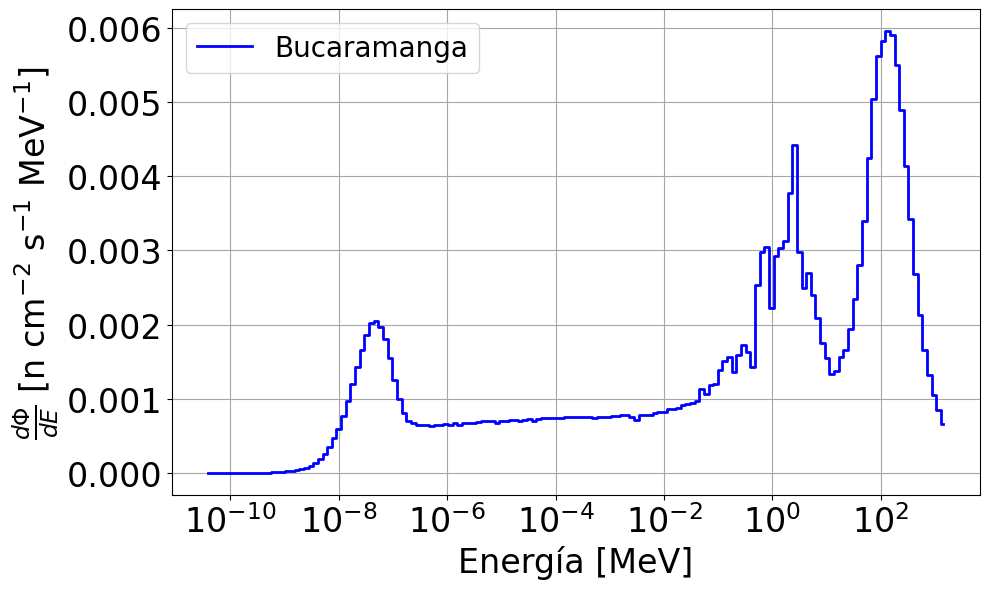

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Definir área de detección (cm²) y tiempos de integración (s)
A = (40000)**2  # Área en cm²
time_default = 12 * 3600 / (400**2)  # Tiempo por defecto en segundos
time_mcg = (1/4) * 3600 / (400**2)  # Tiempo específico para (1 hora en segundos, ajusta según necesites)

# Lista de archivos de entrada y sus tiempos correspondientes
#input_file1 = "all_neutron_yny_SAN11.shw"
input_file2 = "all_bga_neutron_35.shw"
files = [input_file2]
times = [time_mcg]  # Lista de tiempos para cada archivo
labels = ["Bucaramanga"]

# Función para procesar los archivos y graficar solo el flujo letárgico
def neutron_flux(files, times, output_pdf_name, A):
    """
    Procesa múltiples archivos de flujos de neutrones y grafica solo el flujo letárgico.
    
    :param files: Lista de archivos de entrada.
    :param times: Lista de tiempos de integración (s) para cada archivo.
    :param output_pdf_name: Nombre del archivo de salida para la gráfica.
    :param A: Área de detección (cm²).
    """
    m = 939.6  # Masa del neutrón en MeV/c^2
    plt.figure(figsize=(10, 6))  # Crear figura
    colors = ['b', 'r', 'g', 'm', 'c', 'y', 'k']  # Colores para diferenciar curvas
    
    for i, file in enumerate(files):
        # Usar el tiempo correspondiente a este archivo
        time = times[i]
        
        # Leer el archivo CSV con formato adecuado
        df = pd.read_csv(file, delimiter=" ", skiprows=1, skipinitialspace=True, comment="#", on_bad_lines='skip')
        df.columns = ["particle", "px", "py", "pz", "x", "y", "z", "shower_id", "prm_id", "prm_energy", "prm_theta", "prm_phi"]
        
        # Filtrar solo los neutrones
        df_neutrons = df[df["particle"] == "neutron"].copy()
        
        # Calcular la energía cinética (Ek) usando la fórmula Ek = (p² / 2m)
        df_neutrons["Ek"] = (df_neutrons["px"]**2 + df_neutrons["py"]**2 + df_neutrons["pz"]**2) / (2 * m)
        
        # Filtrar energías válidas (Ek < 1573 MeV y Ek != 0)
        df_neutrons = df_neutrons[(df_neutrons["Ek"] < 1573.0) & (df_neutrons["Ek"] != 0)]
        neu_Ek = np.array(df_neutrons["Ek"])
        
        # Definir bins logarítmicos para energía
        min_Ek, max_Ek = np.min(neu_Ek), np.max(neu_Ek)
        num_bins = 159
        bins_Ek = np.logspace(np.log10(min_Ek), np.log10(max_Ek), num_bins + 1)
        
        # Calcular histograma de energía cinética
        y_diff, _ = np.histogram(neu_Ek, bins=bins_Ek, density=False)
        bin_centers = (bins_Ek[1:] + bins_Ek[:-1]) / 2  # Centros de los bins
        bin_widths = bins_Ek[1:] - bins_Ek[:-1]  # Ancho de los bins
        
        # Calcular flujo diferencial
        phi_diff = y_diff / (A * time * bin_centers)
        
        # Calcular flujo letárgico: φ_lethargy(u) = φ_diff(E) * E_mid
        phi_lethargy = phi_diff * bin_centers
        
        # Graficar flujo letárgico
        color = colors[i % len(colors)]  # Ciclar colores si hay más archivos
        plt.step(bin_centers, phi_lethargy, color=color, where='mid', label=f'{labels[i]}', linewidth=2)
    
    # Configuración de la gráfica
    plt.xscale('log')  # Escala logarítmica en el eje X
    plt.xlabel('Energía [MeV]', size=24)
    #plt.ylabel('Thermal flux [n·cm⁻²·s⁻¹]', size=24)
    #plt.ylabel('Flujo [n·cm⁻²·s⁻¹MeV⁻¹]', size=24)
    plt.ylabel(r'$\frac{d\Phi}{dE}$ [n cm$^{-2}$ s$^{-1}$ MeV$^{-1}$]',fontsize=24)
    plt.title('', size=20)
    plt.grid(True, which="both", ls="-", color='0.65')
    plt.legend()
    plt.legend(fontsize=20)
    plt.tick_params(labelsize=24)
    
    # Guardar la gráfica en un archivo
    plt.tight_layout()
    plt.savefig(output_pdf_name)
    # Guardar y mostrar
    plt.tight_layout()
    plt.savefig('Flujo_diferencia_neutrones_12h.png', format='png')
    plt.savefig('Flujo_diferencia_neutrones_12h.pdf', format='pdf')
    plt.show()

# Ejecutar la función con los archivos y tiempos especificados
output_name = "Completo_flux_neutrons.png"
neutron_flux(files, times, output_name, A)


In [11]:
# ==========================================================
# ESPECTRO DIFERENCIAL Y LETÁRGICO DE NEUTRONES
# ARTI/CORSIKA – BUCARAMANGA
# ==========================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


# ==========================================================
# CONFIGURACIÓN GENERAL
# ==========================================================

ARCHIVO_ENTRADA = Path(
    "S3_bga_003600_neutrons.shw"
)

DIRECTORIO_SALIDA = Path(
    "Espectros-neutrones-Bucaramanga"
)

DIRECTORIO_SALIDA.mkdir(
    parents=True,
    exist_ok=True
)


# ==========================================================
# NORMALIZACIÓN FÍSICA
# ==========================================================
#
# Área cuadrada de 1 cm de lado:
#
# A = 1 cm × 1 cm = 1 cm²
#
# Tiempo total representado por el archivo:
#
# t = 3600 s
# ==========================================================

LADO_SUPERFICIE_CM = 1.0

AREA_CM2 = (
    LADO_SUPERFICIE_CM**2
)

TIEMPO_EXPOSICION_S = 3600.0


# ==========================================================
# PARÁMETROS FÍSICOS
# ==========================================================

ID_NEUTRON_CORSIKA = 13

# Masa en reposo del neutrón.
MASA_NEUTRON_GEV = 0.9395654205

# Las componentes px, py y pz del archivo se interpretan
# en GeV/c.
UNIDAD_MOMENTO = "GeV/c"


# ==========================================================
# CONFIGURACIÓN DEL HISTOGRAMA
# ==========================================================

NUMERO_BINS = 159

# None utiliza automáticamente todo el intervalo del archivo.
ENERGIA_MIN_MEV = None
ENERGIA_MAX_MEV = None

# Para restringir manualmente el intervalo, puedes usar:
#
# ENERGIA_MIN_MEV = 1.0e-8
# ENERGIA_MAX_MEV = 1.0e5


# ==========================================================
# OPCIONES DE LA FIGURA
# ==========================================================

FIGSIZE = (
    12.5,
    7.8
)

DPI = 600

COLOR_CURVA = "navy"

MOSTRAR_INCERTIDUMBRE = True
MOSTRAR_RECUADRO = True


# ==========================================================
# NOMBRES DE SALIDA
# ==========================================================

ARCHIVO_DIFERENCIAL_PNG = (
    DIRECTORIO_SALIDA
    / "Flujo-diferencial-neutrones-Bucaramanga.png"
)

ARCHIVO_DIFERENCIAL_PDF = (
    DIRECTORIO_SALIDA
    / "Flujo-diferencial-neutrones-Bucaramanga.pdf"
)

ARCHIVO_LETARGICO_PNG = (
    DIRECTORIO_SALIDA
    / "Flujo-letargico-neutrones-Bucaramanga.png"
)

ARCHIVO_LETARGICO_PDF = (
    DIRECTORIO_SALIDA
    / "Flujo-letargico-neutrones-Bucaramanga.pdf"
)

ARCHIVO_RESULTADOS_CSV = (
    DIRECTORIO_SALIDA
    / "Espectros-neutrones-Bucaramanga.csv"
)

ARCHIVO_RESUMEN_TXT = (
    DIRECTORIO_SALIDA
    / "Resumen-espectro-neutrones-Bucaramanga.txt"
)


# ==========================================================
# COLUMNAS DEL ARCHIVO ARTI/CORSIKA
# ==========================================================

COLUMNAS = [
    "particle",
    "px",
    "py",
    "pz",
    "x",
    "y",
    "z",
    "shower_id",
    "prm_id",
    "prm_energy",
    "prm_theta",
    "prm_phi"
]


# ==========================================================
# CONFIGURACIÓN TIPOGRÁFICA
# ==========================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": [
        "DejaVu Serif"
    ],
    "mathtext.fontset": "dejavuserif",

    "font.size": 16,
    "axes.labelsize": 22,
    "xtick.labelsize": 17,
    "ytick.labelsize": 17,
    "legend.fontsize": 15,

    "axes.linewidth": 1.0,

    # Fuentes editables en PDF.
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})


# ==========================================================
# LEER ARCHIVO
# ==========================================================

def leer_archivo(nombre_archivo):
    """
    Lee un archivo ARTI/CORSIKA sin encabezado.

    Se espera que el archivo tenga al menos 12 columnas.
    """

    if not nombre_archivo.exists():

        raise FileNotFoundError(
            f"No se encontró el archivo:\n"
            f"{nombre_archivo.resolve()}"
        )

    datos = pd.read_csv(
        nombre_archivo,
        sep=r"\s+",
        comment="#",
        header=None,
        on_bad_lines="skip"
    )

    if datos.shape[1] < len(COLUMNAS):

        raise ValueError(
            f"El archivo contiene "
            f"{datos.shape[1]} columnas, pero se "
            f"esperaban al menos {len(COLUMNAS)}."
        )

    datos = datos.iloc[
        :,
        :len(COLUMNAS)
    ].copy()

    datos.columns = COLUMNAS

    return datos


# ==========================================================
# SELECCIONAR NEUTRONES
# ==========================================================

def seleccionar_neutrones(datos):
    """
    Selecciona las partículas con CORSIKA ID = 13.

    También admite archivos donde la partícula se encuentre
    escrita como 'neutron'.
    """

    particle_text = (
        datos["particle"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    mascara_texto = particle_text.isin([
        "neutron",
        "neutrons",
        "n"
    ])

    particle_numeric = pd.to_numeric(
        datos["particle"],
        errors="coerce"
    )

    mascara_id = (
        particle_numeric
        == ID_NEUTRON_CORSIKA
    )

    neutrones = datos[
        mascara_texto
        | mascara_id
    ].copy()

    if neutrones.empty:

        raise ValueError(
            "No se encontraron neutrones en el archivo. "
            "Revisa la columna particle y el identificador "
            "CORSIKA."
        )

    return neutrones


# ==========================================================
# CALCULAR ENERGÍA CINÉTICA
# ==========================================================

def calcular_energia_cinetica(neutrones):
    """
    Calcula la energía cinética relativista:

        E_k = sqrt(p² + m²) - m

    donde el momento está en GeV/c y la energía resultante
    se convierte a MeV.
    """

    componentes = [
        "px",
        "py",
        "pz"
    ]

    for componente in componentes:

        neutrones[componente] = pd.to_numeric(
            neutrones[componente],
            errors="coerce"
        )

    neutrones = neutrones.dropna(
        subset=componentes
    ).copy()

    px = neutrones["px"].to_numpy(
        dtype=float
    )

    py = neutrones["py"].to_numpy(
        dtype=float
    )

    pz = neutrones["pz"].to_numpy(
        dtype=float
    )

    # Momento total en GeV/c.
    momento_GeV_c = np.sqrt(
        px**2
        + py**2
        + pz**2
    )

    # Energía total relativista en GeV.
    energia_total_GeV = np.sqrt(
        momento_GeV_c**2
        + MASA_NEUTRON_GEV**2
    )

    # Energía cinética en GeV.
    energia_cinetica_GeV = (
        energia_total_GeV
        - MASA_NEUTRON_GEV
    )

    # Conversión GeV -> MeV.
    energia_cinetica_MeV = (
        energia_cinetica_GeV
        * 1000.0
    )

    neutrones["momento_GeV_c"] = (
        momento_GeV_c
    )

    neutrones["energia_cinetica_MeV"] = (
        energia_cinetica_MeV
    )

    mascara_valida = (
        np.isfinite(
            neutrones["energia_cinetica_MeV"]
        )
        & (
            neutrones["energia_cinetica_MeV"]
            > 0.0
        )
    )

    neutrones = neutrones[
        mascara_valida
    ].copy()

    if neutrones.empty:

        raise ValueError(
            "No se encontraron energías cinéticas "
            "positivas y finitas."
        )

    return neutrones


# ==========================================================
# DETERMINAR EL INTERVALO ENERGÉTICO
# ==========================================================

def determinar_intervalo(energias):
    """
    Determina el intervalo energético del histograma.
    """

    minimo_datos = float(
        np.min(energias)
    )

    maximo_datos = float(
        np.max(energias)
    )

    if ENERGIA_MIN_MEV is None:

        energia_minima = minimo_datos

    else:

        energia_minima = float(
            ENERGIA_MIN_MEV
        )

    if ENERGIA_MAX_MEV is None:

        energia_maxima = maximo_datos

    else:

        energia_maxima = float(
            ENERGIA_MAX_MEV
        )

    if energia_minima <= 0:

        raise ValueError(
            "La energía mínima debe ser positiva."
        )

    if energia_maxima <= energia_minima:

        raise ValueError(
            "La energía máxima debe ser mayor "
            "que la energía mínima."
        )

    return (
        energia_minima,
        energia_maxima
    )


# ==========================================================
# FORMATO DE EJES
# ==========================================================

def configurar_ejes(
    ax,
    xlabel,
    ylabel
):
    """
    Aplica formato científico a los ejes.
    """

    ax.set_xscale(
        "log"
    )

    ax.set_yscale(
        "log"
    )

    ax.set_xlabel(
        xlabel,
        labelpad=12
    )

    ax.set_ylabel(
        ylabel,
        labelpad=15
    )

    ax.xaxis.set_major_locator(
        ticker.LogLocator(
            base=10,
            numticks=12
        )
    )

    ax.xaxis.set_minor_locator(
        ticker.LogLocator(
            base=10,
            subs=np.arange(2, 10) * 0.1,
            numticks=100
        )
    )

    ax.yaxis.set_major_locator(
        ticker.LogLocator(
            base=10,
            numticks=12
        )
    )

    ax.yaxis.set_minor_locator(
        ticker.LogLocator(
            base=10,
            subs=np.arange(2, 10) * 0.1,
            numticks=100
        )
    )

    ax.xaxis.set_major_formatter(
        ticker.LogFormatterMathtext()
    )

    ax.yaxis.set_major_formatter(
        ticker.LogFormatterMathtext()
    )

    ax.xaxis.set_minor_formatter(
        ticker.NullFormatter()
    )

    ax.yaxis.set_minor_formatter(
        ticker.NullFormatter()
    )

    ax.tick_params(
        axis="both",
        which="major",
        direction="in",
        length=7,
        width=1.0,
        top=True,
        right=True
    )

    ax.tick_params(
        axis="both",
        which="minor",
        direction="in",
        length=3.5,
        width=0.65,
        top=True,
        right=True
    )

    ax.grid(
        visible=True,
        which="major",
        axis="both",
        linestyle="--",
        linewidth=0.55,
        color="0.50",
        alpha=0.27
    )

    ax.grid(
        visible=True,
        which="minor",
        axis="both",
        linestyle=":",
        linewidth=0.30,
        color="0.60",
        alpha=0.08
    )

    ax.set_axisbelow(
        True
    )

    for spine in ax.spines.values():

        spine.set_linewidth(
            1.0
        )

        spine.set_color(
            "0.20"
        )


# ==========================================================
# CREAR FIGURA
# ==========================================================

def crear_figura(
    bordes,
    centros,
    valores,
    incertidumbres,
    etiqueta_y,
    texto_informacion,
    archivo_png,
    archivo_pdf
):
    """
    Genera y guarda una figura del espectro.
    """

    fig, ax = plt.subplots(
        figsize=FIGSIZE,
        constrained_layout=True
    )

    # Los ceros se reemplazan por NaN para evitar problemas
    # con la escala logarítmica.
    valores_visibles = np.where(
        valores > 0.0,
        valores,
        np.nan
    )

    ax.stairs(
        valores_visibles,
        bordes,
        color=COLOR_CURVA,
        linewidth=2.2,
        label=(
            "Neutrones secundarios – "
            "ARTI/CORSIKA"
        ),
        zorder=5
    )

    if MOSTRAR_INCERTIDUMBRE:

        limite_inferior = np.where(
            valores
            - incertidumbres
            > 0.0,
            valores
            - incertidumbres,
            np.nan
        )

        limite_superior = np.where(
            valores > 0.0,
            valores
            + incertidumbres,
            np.nan
        )

        ax.fill_between(
            centros,
            limite_inferior,
            limite_superior,
            step="mid",
            alpha=0.16,
            linewidth=0,
            label=(
                r"Incertidumbre estadística "
                r"$\sqrt{N_i}$"
            ),
            zorder=3
        )

    configurar_ejes(
        ax=ax,
        xlabel=(
            r"Energía cinética del neutrón, "
            r"$E_n$ [MeV]"
        ),
        ylabel=etiqueta_y
    )

    if MOSTRAR_RECUADRO:

        ax.text(
            0.025,
            0.965,
            texto_informacion,
            transform=ax.transAxes,
            fontsize=13.5,
            ha="left",
            va="top",
            color="0.20",
            bbox={
                "facecolor": "white",
                "edgecolor": "0.70",
                "linewidth": 0.7,
                "boxstyle": "round,pad=0.40",
                "alpha": 0.94
            },
            zorder=10
        )

    leyenda = ax.legend(
        loc="upper right",
        frameon=True,
        framealpha=0.95,
        facecolor="white",
        edgecolor="0.70",
        borderpad=0.60,
        labelspacing=0.45,
        handlelength=2.8
    )

    leyenda.get_frame().set_linewidth(
        0.75
    )

    fig.savefig(
        archivo_png,
        dpi=DPI,
        format="png",
        bbox_inches="tight",
        pad_inches=0.05,
        facecolor="white"
    )

    fig.savefig(
        archivo_pdf,
        format="pdf",
        bbox_inches="tight",
        pad_inches=0.05,
        facecolor="white"
    )

    plt.show()

    plt.close(
        fig
    )


# ==========================================================
# PROGRAMA PRINCIPAL
# ==========================================================

def main():

    # ------------------------------------------------------
    # Leer y procesar datos
    # ------------------------------------------------------

    datos = leer_archivo(
        ARCHIVO_ENTRADA
    )

    neutrones = seleccionar_neutrones(
        datos
    )

    neutrones = calcular_energia_cinetica(
        neutrones
    )

    energias_MeV = (
        neutrones["energia_cinetica_MeV"]
        .to_numpy(dtype=float)
    )

    numero_neutrones_total = len(
        energias_MeV
    )

    # ------------------------------------------------------
    # Intervalo de energía
    # ------------------------------------------------------

    energia_minima, energia_maxima = (
        determinar_intervalo(
            energias_MeV
        )
    )

    mascara_intervalo = (
        (energias_MeV >= energia_minima)
        & (energias_MeV <= energia_maxima)
    )

    energias_filtradas = energias_MeV[
        mascara_intervalo
    ]

    numero_neutrones_intervalo = len(
        energias_filtradas
    )

    if numero_neutrones_intervalo == 0:

        raise ValueError(
            "No existen neutrones dentro del "
            "intervalo energético seleccionado."
        )

    # ------------------------------------------------------
    # Bins logarítmicos
    # ------------------------------------------------------

    bordes = np.logspace(
        np.log10(
            energia_minima
        ),
        np.log10(
            energia_maxima
        ),
        NUMERO_BINS + 1
    )

    # Centro geométrico de cada bin.
    centros = np.sqrt(
        bordes[:-1]
        * bordes[1:]
    )

    # Ancho energético.
    delta_E = np.diff(
        bordes
    )

    # Ancho de letargía.
    delta_u = np.log(
        bordes[1:]
        / bordes[:-1]
    )

    cuentas, _ = np.histogram(
        energias_filtradas,
        bins=bordes
    )

    cuentas = cuentas.astype(
        float
    )

    # ------------------------------------------------------
    # Flujo diferencial
    # ------------------------------------------------------
    #
    # dPhi/dE = N_i / (A t DeltaE_i)
    #
    # Unidades:
    # n cm^-2 s^-1 MeV^-1
    # ------------------------------------------------------

    flujo_diferencial = (
        cuentas
        / (
            AREA_CM2
            * TIEMPO_EXPOSICION_S
            * delta_E
        )
    )

    incertidumbre_diferencial = (
        np.sqrt(cuentas)
        / (
            AREA_CM2
            * TIEMPO_EXPOSICION_S
            * delta_E
        )
    )

    # ------------------------------------------------------
    # Flujo por unidad de letargía
    # ------------------------------------------------------
    #
    # dPhi/du = N_i / (A t Delta_u_i)
    #
    # Unidades:
    # n cm^-2 s^-1
    # ------------------------------------------------------

    flujo_letargico = (
        cuentas
        / (
            AREA_CM2
            * TIEMPO_EXPOSICION_S
            * delta_u
        )
    )

    incertidumbre_letargica = (
        np.sqrt(cuentas)
        / (
            AREA_CM2
            * TIEMPO_EXPOSICION_S
            * delta_u
        )
    )

    # ------------------------------------------------------
    # Magnitudes integradas
    # ------------------------------------------------------

    fluencia = (
        numero_neutrones_intervalo
        / AREA_CM2
    )

    flujo_integrado = (
        numero_neutrones_intervalo
        / (
            AREA_CM2
            * TIEMPO_EXPOSICION_S
        )
    )

    # Comprobación mediante integración discreta.
    flujo_desde_diferencial = np.sum(
        flujo_diferencial
        * delta_E
    )

    flujo_desde_letargia = np.sum(
        flujo_letargico
        * delta_u
    )

    # ------------------------------------------------------
    # Información para las figuras
    # ------------------------------------------------------

    texto_informacion = (
        "Simulación ARTI/CORSIKA\n"
        "Bucaramanga, Colombia\n"
        f"Tiempo de exposición: "
        f"{TIEMPO_EXPOSICION_S:.0f} s\n"
        f"Área efectiva: "
        f"{AREA_CM2:.2f} cm²\n"
        f"Número de neutrones: "
        f"{numero_neutrones_intervalo:,}\n"
        f"Flujo integrado: "
        f"{flujo_integrado:.3e} "
        r"n cm$^{-2}$ s$^{-1}$"
    )

    # ------------------------------------------------------
    # Figura del flujo diferencial
    # ------------------------------------------------------

    crear_figura(
        bordes=bordes,
        centros=centros,
        valores=flujo_diferencial,
        incertidumbres=incertidumbre_diferencial,
        etiqueta_y=(
            r"Flujo diferencial de neutrones, "
            r"$\mathrm{d}\Phi_n/\mathrm{d}E$ "
            r"[$\mathrm{n\,cm^{-2}\,s^{-1}\,"
            r"MeV^{-1}}$]"
        ),
        texto_informacion=texto_informacion,
        archivo_png=ARCHIVO_DIFERENCIAL_PNG,
        archivo_pdf=ARCHIVO_DIFERENCIAL_PDF
    )

    # ------------------------------------------------------
    # Figura del flujo letárgico
    # ------------------------------------------------------

    crear_figura(
        bordes=bordes,
        centros=centros,
        valores=flujo_letargico,
        incertidumbres=incertidumbre_letargica,
        etiqueta_y=(
            r"Flujo por unidad de letargía, "
            r"$\mathrm{d}\Phi_n/\mathrm{d}u$ "
            r"[$\mathrm{n\,cm^{-2}\,s^{-1}}$]"
        ),
        texto_informacion=texto_informacion,
        archivo_png=ARCHIVO_LETARGICO_PNG,
        archivo_pdf=ARCHIVO_LETARGICO_PDF
    )

    # ------------------------------------------------------
    # Guardar tabla numérica
    # ------------------------------------------------------

    resultados = pd.DataFrame({
        "E_min_MeV":
            bordes[:-1],

        "E_max_MeV":
            bordes[1:],

        "E_centro_MeV":
            centros,

        "Delta_E_MeV":
            delta_E,

        "Delta_u":
            delta_u,

        "cuentas":
            cuentas.astype(int),

        "dPhi_dE_n_cm-2_s-1_MeV-1":
            flujo_diferencial,

        "sigma_dPhi_dE":
            incertidumbre_diferencial,

        "dPhi_du_n_cm-2_s-1":
            flujo_letargico,

        "sigma_dPhi_du":
            incertidumbre_letargica
    })

    resultados.to_csv(
        ARCHIVO_RESULTADOS_CSV,
        index=False,
        float_format="%.10e"
    )

    # ------------------------------------------------------
    # Guardar resumen
    # ------------------------------------------------------

    resumen = (
        "ESPECTRO DE NEUTRONES ARTI/CORSIKA\n"
        "============================================\n\n"

        f"Archivo de entrada:\n"
        f"{ARCHIVO_ENTRADA.resolve()}\n\n"

        f"Ciudad: Bucaramanga, Colombia\n"
        f"Unidad del momento: {UNIDAD_MOMENTO}\n\n"

        f"Tiempo de exposición:\n"
        f"{TIEMPO_EXPOSICION_S:.6e} s\n\n"

        f"Lado de la superficie:\n"
        f"{LADO_SUPERFICIE_CM:.6e} cm\n\n"

        f"Área efectiva:\n"
        f"{AREA_CM2:.6e} cm²\n\n"

        f"Número total de neutrones:\n"
        f"{numero_neutrones_total:,}\n\n"

        f"Neutrones en el intervalo:\n"
        f"{numero_neutrones_intervalo:,}\n\n"

        f"Energía mínima:\n"
        f"{energia_minima:.10e} MeV\n\n"

        f"Energía máxima:\n"
        f"{energia_maxima:.10e} MeV\n\n"

        f"Fluencia:\n"
        f"{fluencia:.10e} n cm^-2\n\n"

        f"Flujo integrado:\n"
        f"{flujo_integrado:.10e} "
        f"n cm^-2 s^-1\n\n"

        "COMPROBACIONES NUMÉRICAS\n"
        "--------------------------------------------\n"

        f"Integral del flujo diferencial:\n"
        f"{flujo_desde_diferencial:.10e} "
        f"n cm^-2 s^-1\n\n"

        f"Integral del flujo letárgico:\n"
        f"{flujo_desde_letargia:.10e} "
        f"n cm^-2 s^-1\n"
    )

    with open(
        ARCHIVO_RESUMEN_TXT,
        "w",
        encoding="utf-8"
    ) as archivo:

        archivo.write(
            resumen
        )

    # ------------------------------------------------------
    # Mostrar resultados
    # ------------------------------------------------------

    print(
        "\n"
        + resumen
    )

    print(
        "\nARCHIVOS GENERADOS"
    )

    print(
        "============================================"
    )

    print(
        ARCHIVO_DIFERENCIAL_PNG.resolve()
    )

    print(
        ARCHIVO_DIFERENCIAL_PDF.resolve()
    )

    print(
        ARCHIVO_LETARGICO_PNG.resolve()
    )

    print(
        ARCHIVO_LETARGICO_PDF.resolve()
    )

    print(
        ARCHIVO_RESULTADOS_CSV.resolve()
    )

    print(
        ARCHIVO_RESUMEN_TXT.resolve()
    )


# ==========================================================
# EJECUTAR
# ==========================================================

if __name__ == "__main__":
    main()

FileNotFoundError: No se encontró el archivo:
/media/ubuntu/TOSHIBA EXT/Tesis-doctorado-julio-2026-portatil/Simulaciones-Jaime-2024/Flujo-termico-suelo-seco/S3_bga_003600_neutrons.shw

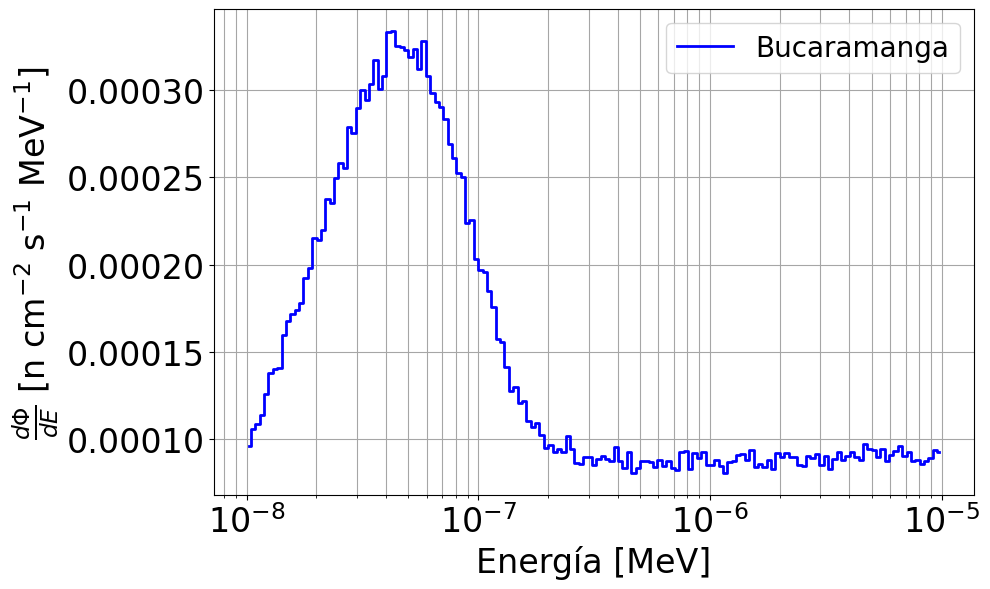

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Definir área de detección (cm²) y tiempos de integración (s)
A = (40000)**2  # Área en cm²
time_default = 12 * 3600 / (400**2)  # Tiempo por defecto en segundos
time_mcg = (1/4) * 3600 / (400**2)  # Tiempo específico para (1 hora en segundos, ajusta según necesites)

# Lista de archivos de entrada y sus tiempos correspondientes
#input_file1 = "all_neutron_yny_SAN11.shw"
input_file2 = "filtered_neutrons.shw"
files = [input_file2]
times = [time_mcg]  # Lista de tiempos para cada archivo
labels = ["Bucaramanga"]

# Función para procesar los archivos y graficar solo el flujo letárgico
def neutron_flux(files, times, output_pdf_name, A):
    """
    Procesa múltiples archivos de flujos de neutrones y grafica solo el flujo letárgico.
    
    :param files: Lista de archivos de entrada.
    :param times: Lista de tiempos de integración (s) para cada archivo.
    :param output_pdf_name: Nombre del archivo de salida para la gráfica.
    :param A: Área de detección (cm²).
    """
    m = 939.6  # Masa del neutrón en MeV/c^2
    plt.figure(figsize=(10, 6))  # Crear figura
    colors = ['b', 'r', 'g', 'm', 'c', 'y', 'k']  # Colores para diferenciar curvas
    
    for i, file in enumerate(files):
        # Usar el tiempo correspondiente a este archivo
        time = times[i]
        
        # Leer el archivo CSV con formato adecuado
        df = pd.read_csv(file, delimiter=" ", skiprows=1, skipinitialspace=True, comment="#", on_bad_lines='skip')
        df.columns = ["particle", "px", "py", "pz", "x", "y", "z", "shower_id", "prm_id", "prm_energy", "prm_theta", "prm_phi"]
        
        # Filtrar solo los neutrones
        df_neutrons = df[df["particle"] == "neutron"].copy()
        
        # Calcular la energía cinética (Ek) usando la fórmula Ek = (p² / 2m)
        df_neutrons["Ek"] = (df_neutrons["px"]**2 + df_neutrons["py"]**2 + df_neutrons["pz"]**2) / (2 * m)
        
        # Filtrar energías válidas (Ek < 1573 MeV y Ek != 0)
        df_neutrons = df_neutrons[(df_neutrons["Ek"] < 1573.0) & (df_neutrons["Ek"] != 0)]
        neu_Ek = np.array(df_neutrons["Ek"])
        
        # Definir bins logarítmicos para energía
        min_Ek, max_Ek = np.min(neu_Ek), np.max(neu_Ek)
        num_bins = 159
        bins_Ek = np.logspace(np.log10(min_Ek), np.log10(max_Ek), num_bins + 1)
        
        # Calcular histograma de energía cinética
        y_diff, _ = np.histogram(neu_Ek, bins=bins_Ek, density=False)
        bin_centers = (bins_Ek[1:] + bins_Ek[:-1]) / 2  # Centros de los bins
        bin_widths = bins_Ek[1:] - bins_Ek[:-1]  # Ancho de los bins
        
        # Calcular flujo diferencial
        phi_diff = y_diff / (A * time * bin_centers)
        
        # Calcular flujo letárgico: φ_lethargy(u) = φ_diff(E) * E_mid
        phi_lethargy = phi_diff * bin_centers
        
        # Graficar flujo letárgico
        color = colors[i % len(colors)]  # Ciclar colores si hay más archivos
        plt.step(bin_centers, phi_lethargy, color=color, where='mid', label=f'{labels[i]}', linewidth=2)
    
    # Configuración de la gráfica
    plt.xscale('log')  # Escala logarítmica en el eje X
    plt.xlabel('Energía [MeV]', size=24)
    #plt.ylabel('Thermal flux [n·cm⁻²·s⁻¹]', size=24)
    #plt.ylabel('dphi/dE [n·cm⁻²·s⁻¹·MeV⁻¹]', size=24)
    plt.ylabel(r'$\frac{d\Phi}{dE}$ [n cm$^{-2}$ s$^{-1}$ MeV$^{-1}$]',fontsize=24)
    plt.title('', size=20)
    plt.grid(True, which="both", ls="-", color='0.65')
    plt.legend()
    plt.legend(fontsize=20)
    plt.tick_params(labelsize=24)
    
    # Guardar la gráfica en un archivo
    plt.tight_layout()
    plt.savefig(output_pdf_name)
    # Guardar y mostrar
    plt.tight_layout()
    plt.savefig('Flujo_diferencial_termico.png', format='png')
    plt.savefig('Flujo_diferencial_termico.pdf', format='pdf')
    plt.show()

# Ejecutar la función con los archivos y tiempos especificados
output_name = "Thermal_flux_neutrons.png"
neutron_flux(files, times, output_name, A)

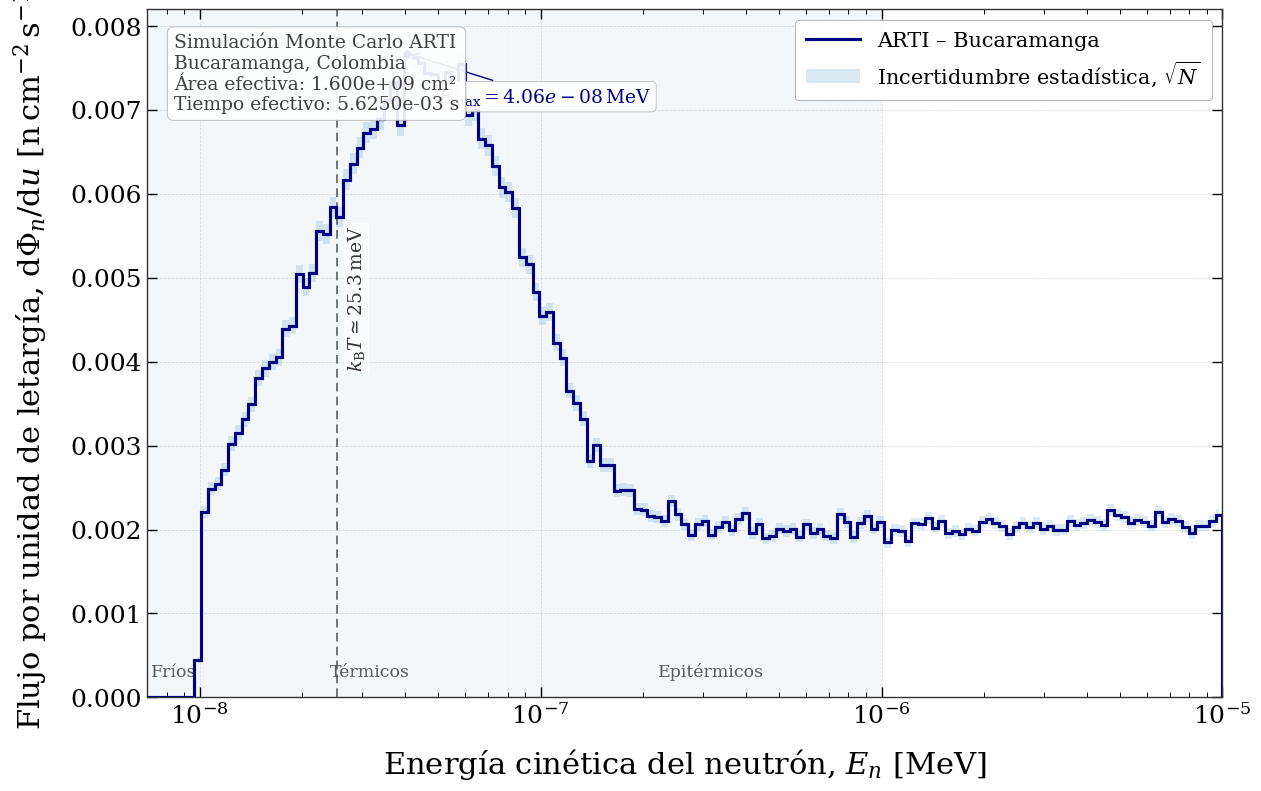


Figura generada correctamente.
--------------------------------
Directorio: /media/ubuntu/TOSHIBA EXT/Tesis-doctorado-julio-2026-portatil/Simulaciones-Jaime-2024/Flujo-termico-suelo-seco/Graficas-flujo-termico
PDF: Graficas-flujo-termico/Flujo-termico-neutrones-Bucaramanga.pdf
PNG: Graficas-flujo-termico/Flujo-termico-neutrones-Bucaramanga.png
JPG: Graficas-flujo-termico/Flujo-termico-neutrones-Bucaramanga.jpg
Resultados numéricos: Graficas-flujo-termico/Flujo-termico-neutrones-Bucaramanga-datos.txt
Área efectiva: 1.600000e+09 cm²

ARTI – Bucaramanga
  Tiempo efectivo: 5.625000e-03 s
  Neutrones totales: 207,969
  Neutrones en intervalo: 207,967


In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


# ==========================================================
# CONFIGURACIÓN GENERAL
# ==========================================================

DIRECTORIO_SALIDA = "Graficas-flujo-termico"

NOMBRE_BASE = "Flujo-termico-neutrones-Bucaramanga"

os.makedirs(
    DIRECTORIO_SALIDA,
    exist_ok=True
)

ARCHIVO_PDF = os.path.join(
    DIRECTORIO_SALIDA,
    NOMBRE_BASE + ".pdf"
)

ARCHIVO_PNG = os.path.join(
    DIRECTORIO_SALIDA,
    NOMBRE_BASE + ".png"
)

ARCHIVO_JPG = os.path.join(
    DIRECTORIO_SALIDA,
    NOMBRE_BASE + ".jpg"
)

ARCHIVO_RESULTADOS = os.path.join(
    DIRECTORIO_SALIDA,
    NOMBRE_BASE + "-datos.txt"
)


# ==========================================================
# ARCHIVOS DE ENTRADA
# ==========================================================

files = [
    "filtered_neutrons.shw"
]

labels = [
    "ARTI – Bucaramanga"
]


# ==========================================================
# ÁREA Y TIEMPO EFECTIVOS
# ==========================================================
#
# IMPORTANTE:
# Estos valores deben representar el área y el tiempo físicos
# efectivos asociados con el archivo ARTI.
#
# En el código original:
#
# A = (40000)^2 cm²
# t = (1/4)*3600/(400)^2 s
#
# Se conserva esta normalización, pero debe comprobarse que el
# factor 400² corresponda realmente al procedimiento utilizado
# en la simulación.
# ==========================================================

AREA_CM2 = (40000.0)**2

TIEMPO_DEFAULT_S = (
    12.0 * 3600.0 / (400.0**2)
)

TIEMPO_MCG_S = (
    0.25 * 3600.0 / (400.0**2)
)

times = [
    TIEMPO_MCG_S
]


# ==========================================================
# PARÁMETROS FÍSICOS
# ==========================================================

MASA_NEUTRON_MEV = 939.5654205

# Unidad de las componentes px, py y pz del archivo.
#
# Opciones admitidas:
# "MeV/c"
# "GeV/c"
UNIDAD_MOMENTO = "MeV/c"

# Identificador numérico del neutrón cuando la columna
# particle no contiene texto.
ID_NEUTRON_CORSIKA = 13


# ==========================================================
# INTERVALO ENERGÉTICO Y BINNING
# ==========================================================

# Intervalo mostrado en la figura, en MeV.
#
# 10^-8 MeV = 10 meV
# 10^-5 MeV = 10 eV
ENERGIA_MIN_MEV = 7.0e-9
ENERGIA_MAX_MEV = 1.0e-5

NUMERO_BINS = 159

# Energía térmica de referencia a temperatura ambiente:
#
# 25.3 meV = 2.53e-8 MeV
ENERGIA_TERMICA_MEV = 2.53e-8


# ==========================================================
# REGIONES ENERGÉTICAS
# ==========================================================
#
# Límites expresados en MeV.
#
# Fríos:
# 0.002–0.01 eV = 2e-9–1e-8 MeV
#
# Térmicos:
# 0.01–0.1 eV = 1e-8–1e-7 MeV
#
# Epitérmicos:
# 0.1–1 eV = 1e-7–1e-6 MeV
# ==========================================================

REGIONES_ENERGIA = [
    {
        "nombre": "Fríos",
        "emin": 2.0e-9,
        "emax": 1.0e-8
    },
    {
        "nombre": "Térmicos",
        "emin": 1.0e-8,
        "emax": 1.0e-7
    },
    {
        "nombre": "Epitérmicos",
        "emin": 1.0e-7,
        "emax": 1.0e-6
    }
]


# ==========================================================
# CONFIGURACIÓN VISUAL
# ==========================================================

MOSTRAR_REGIONES = True
MOSTRAR_REFERENCIA_TERMICA = True
MOSTRAR_INCERTIDUMBRE = True
MOSTRAR_MAXIMO = True

COLOR_CURVA = "navy"

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",

    "font.size": 16,
    "axes.labelsize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,

    "axes.linewidth": 1.0,

    # Fuentes editables en PDF
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})


# ==========================================================
# NOMBRES DE LAS COLUMNAS
# ==========================================================

COLUMNAS = [
    "particle",
    "px",
    "py",
    "pz",
    "x",
    "y",
    "z",
    "shower_id",
    "prm_id",
    "prm_energy",
    "prm_theta",
    "prm_phi"
]


# ==========================================================
# LECTURA DEL ARCHIVO
# ==========================================================

def leer_archivo_particulas(nombre_archivo):
    """
    Lee un archivo ARTI/CORSIKA separado por espacios.

    El método intenta funcionar tanto con archivos que poseen
    encabezado como con archivos sin encabezado.
    """

    if not os.path.exists(nombre_archivo):
        raise FileNotFoundError(
            f"No se encontró el archivo: {nombre_archivo}"
        )

    datos = pd.read_csv(
        nombre_archivo,
        sep=r"\s+",
        comment="#",
        header=None,
        on_bad_lines="skip"
    )

    if datos.shape[1] < len(COLUMNAS):
        raise ValueError(
            f"El archivo {nombre_archivo} contiene "
            f"{datos.shape[1]} columnas, pero se esperaban "
            f"al menos {len(COLUMNAS)}."
        )

    # Conservar únicamente las primeras doce columnas.
    datos = datos.iloc[
        :,
        :len(COLUMNAS)
    ].copy()

    datos.columns = COLUMNAS

    return datos


# ==========================================================
# SELECCIÓN ROBUSTA DE NEUTRONES
# ==========================================================

def seleccionar_neutrones(datos):
    """
    Selecciona neutrones cuando la columna particle contiene:

    - la palabra 'neutron' o 'neutrons';
    - el identificador numérico 13.
    """

    columna_texto = (
        datos["particle"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    mascara_texto = columna_texto.isin([
        "neutron",
        "neutrons",
        "n"
    ])

    columna_numerica = pd.to_numeric(
        datos["particle"],
        errors="coerce"
    )

    mascara_numerica = (
        columna_numerica == ID_NEUTRON_CORSIKA
    )

    neutrones = datos[
        mascara_texto | mascara_numerica
    ].copy()

    if neutrones.empty:
        raise ValueError(
            "No se encontraron neutrones. Revisa el contenido "
            "de la columna 'particle' y el identificador usado."
        )

    return neutrones


# ==========================================================
# CALCULAR ENERGÍA CINÉTICA
# ==========================================================

def calcular_energia_cinetica(neutrones):
    """
    Calcula la energía cinética relativista:

        E_k = sqrt(p² + m²) - m

    Se supone c = 1, con p en MeV/c y m en MeV/c².
    """

    for componente in ["px", "py", "pz"]:

        neutrones[componente] = pd.to_numeric(
            neutrones[componente],
            errors="coerce"
        )

    neutrones = neutrones.dropna(
        subset=[
            "px",
            "py",
            "pz"
        ]
    ).copy()

    px = neutrones["px"].to_numpy(dtype=float)
    py = neutrones["py"].to_numpy(dtype=float)
    pz = neutrones["pz"].to_numpy(dtype=float)

    momento = np.sqrt(
        px**2 + py**2 + pz**2
    )

    if UNIDAD_MOMENTO == "GeV/c":

        momento_MeV_c = (
            momento * 1000.0
        )

    elif UNIDAD_MOMENTO == "MeV/c":

        momento_MeV_c = momento

    else:

        raise ValueError(
            "UNIDAD_MOMENTO debe ser 'MeV/c' o 'GeV/c'."
        )

    energia_total_MeV = np.sqrt(
        momento_MeV_c**2
        + MASA_NEUTRON_MEV**2
    )

    energia_cinetica_MeV = (
        energia_total_MeV
        - MASA_NEUTRON_MEV
    )

    neutrones["momento_MeV_c"] = (
        momento_MeV_c
    )

    neutrones["energia_cinetica_MeV"] = (
        energia_cinetica_MeV
    )

    neutrones = neutrones[
        np.isfinite(
            neutrones["energia_cinetica_MeV"]
        )
        & (
            neutrones["energia_cinetica_MeV"]
            > 0
        )
    ].copy()

    return neutrones


# ==========================================================
# PREPARAR BINS LOGARÍTMICOS COMUNES
# ==========================================================

BORDES_ENERGIA_MEV = np.logspace(
    np.log10(ENERGIA_MIN_MEV),
    np.log10(ENERGIA_MAX_MEV),
    NUMERO_BINS + 1
)

CENTROS_ENERGIA_MEV = np.sqrt(
    BORDES_ENERGIA_MEV[:-1]
    * BORDES_ENERGIA_MEV[1:]
)

ANCHOS_ENERGIA_MEV = np.diff(
    BORDES_ENERGIA_MEV
)

# Ancho de cada bin en letargía:
#
# Δu = ln(E_superior/E_inferior)
ANCHOS_LETARGIA = np.log(
    BORDES_ENERGIA_MEV[1:]
    / BORDES_ENERGIA_MEV[:-1]
)


# ==========================================================
# FUNCIÓN PRINCIPAL
# ==========================================================

def neutron_flux(
    files,
    times,
    labels,
    area_cm2
):
    """
    Calcula y grafica el flujo de neutrones por unidad de
    letargía:

        dPhi/du = N_i / (A t Delta_u_i)

    Unidades:

        n cm^-2 s^-1
    """

    if len(files) != len(times):
        raise ValueError(
            "Las listas files y times deben tener la misma "
            "longitud."
        )

    if len(files) != len(labels):
        raise ValueError(
            "Las listas files y labels deben tener la misma "
            "longitud."
        )

    if area_cm2 <= 0:
        raise ValueError(
            "El área efectiva debe ser positiva."
        )

    fig, ax = plt.subplots(
        figsize=(12.5, 7.8),
        constrained_layout=True
    )

    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    resultados = []

    for indice, nombre_archivo in enumerate(files):

        tiempo_s = float(
            times[indice]
        )

        etiqueta = labels[indice]

        if tiempo_s <= 0:
            raise ValueError(
                f"El tiempo asociado con {nombre_archivo} "
                "debe ser positivo."
            )

        # --------------------------------------------------
        # Leer y seleccionar neutrones
        # --------------------------------------------------

        datos = leer_archivo_particulas(
            nombre_archivo
        )

        neutrones = seleccionar_neutrones(
            datos
        )

        neutrones = calcular_energia_cinetica(
            neutrones
        )

        energia_MeV = (
            neutrones["energia_cinetica_MeV"]
            .to_numpy(dtype=float)
        )

        # --------------------------------------------------
        # Filtrar el intervalo mostrado
        # --------------------------------------------------

        mascara_intervalo = (
            (energia_MeV >= ENERGIA_MIN_MEV)
            & (energia_MeV <= ENERGIA_MAX_MEV)
        )

        energia_filtrada_MeV = energia_MeV[
            mascara_intervalo
        ]

        if energia_filtrada_MeV.size == 0:

            raise ValueError(
                f"No existen neutrones dentro del intervalo "
                f"{ENERGIA_MIN_MEV:.3e}–"
                f"{ENERGIA_MAX_MEV:.3e} MeV."
            )

        # --------------------------------------------------
        # Histograma
        # --------------------------------------------------

        cuentas, _ = np.histogram(
            energia_filtrada_MeV,
            bins=BORDES_ENERGIA_MEV
        )

        cuentas = cuentas.astype(float)

        # --------------------------------------------------
        # Flujo diferencial por energía
        # --------------------------------------------------
        #
        # dPhi/dE = N / (A t DeltaE)
        #
        # Unidades:
        # n cm^-2 s^-1 MeV^-1
        # --------------------------------------------------

        flujo_diferencial = (
            cuentas
            / (
                area_cm2
                * tiempo_s
                * ANCHOS_ENERGIA_MEV
            )
        )

        # --------------------------------------------------
        # Flujo por unidad de letargía
        # --------------------------------------------------
        #
        # dPhi/du = N / (A t Delta_u)
        #
        # También:
        #
        # dPhi/du ≈ E dPhi/dE
        # --------------------------------------------------

        flujo_letargico = (
            cuentas
            / (
                area_cm2
                * tiempo_s
                * ANCHOS_LETARGIA
            )
        )

        # --------------------------------------------------
        # Incertidumbre de Poisson
        # --------------------------------------------------

        incertidumbre_flujo = (
            np.sqrt(cuentas)
            / (
                area_cm2
                * tiempo_s
                * ANCHOS_LETARGIA
            )
        )

        # No representar bins vacíos como ceros.
        flujo_visible = np.where(
            flujo_letargico > 0,
            flujo_letargico,
            np.nan
        )

        limite_inferior = np.where(
            flujo_letargico
            - incertidumbre_flujo
            > 0,
            flujo_letargico
            - incertidumbre_flujo,
            np.nan
        )

        limite_superior = np.where(
            flujo_letargico > 0,
            flujo_letargico
            + incertidumbre_flujo,
            np.nan
        )

        # --------------------------------------------------
        # Dibujar la distribución
        # --------------------------------------------------

        ax.stairs(
            flujo_letargico,
            BORDES_ENERGIA_MEV,
            color=COLOR_CURVA,
            linewidth=2.25,
            label=etiqueta,
            zorder=6
        )

        if MOSTRAR_INCERTIDUMBRE:

            ax.fill_between(
                CENTROS_ENERGIA_MEV,
                limite_inferior,
                limite_superior,
                step="mid",
                alpha=0.16,
                linewidth=0,
                zorder=3,
                label=r"Incertidumbre estadística, $\sqrt{N}$"
            )

        # --------------------------------------------------
        # Máximo
        # --------------------------------------------------

        indices_positivos = np.where(
            flujo_letargico > 0
        )[0]

        if indices_positivos.size > 0:

            indice_maximo = int(
                np.nanargmax(
                    flujo_letargico
                )
            )

            energia_maximo = (
                CENTROS_ENERGIA_MEV[
                    indice_maximo
                ]
            )

            flujo_maximo = (
                flujo_letargico[
                    indice_maximo
                ]
            )

            if MOSTRAR_MAXIMO:

                ax.plot(
                    energia_maximo,
                    flujo_maximo,
                    marker="o",
                    markersize=7,
                    markerfacecolor=COLOR_CURVA,
                    markeredgecolor="white",
                    markeredgewidth=0.9,
                    linestyle="none",
                    zorder=9
                )

                ax.annotate(
                    r"$E_{\max}="
                    f"{energia_maximo:.2e}"
                    r"\,\mathrm{MeV}$",
                    xy=(
                        energia_maximo,
                        flujo_maximo
                    ),
                    xytext=(
                        22,
                        -35
                    ),
                    textcoords="offset points",
                    fontsize=13.5,
                    color=COLOR_CURVA,
                    arrowprops=dict(
                        arrowstyle="->",
                        linewidth=1.0,
                        color=COLOR_CURVA
                    ),
                    bbox=dict(
                        facecolor="white",
                        edgecolor="0.70",
                        linewidth=0.6,
                        alpha=0.90,
                        boxstyle="round,pad=0.25"
                    ),
                    zorder=12
                )

        resultados.append({
            "archivo": nombre_archivo,
            "etiqueta": etiqueta,
            "tiempo_s": tiempo_s,
            "neutrones_totales": len(neutrones),
            "neutrones_intervalo": len(
                energia_filtrada_MeV
            ),
            "cuentas": cuentas,
            "flujo_diferencial": flujo_diferencial,
            "flujo_letargico": flujo_letargico,
            "incertidumbre": incertidumbre_flujo
        })

    # ======================================================
    # REGIONES ENERGÉTICAS
    # ======================================================

    if MOSTRAR_REGIONES:

        for indice, region in enumerate(
            REGIONES_ENERGIA
        ):

            xmin = max(
                region["emin"],
                ENERGIA_MIN_MEV
            )

            xmax = min(
                region["emax"],
                ENERGIA_MAX_MEV
            )

            if xmin >= xmax:
                continue

            ax.axvspan(
                xmin,
                xmax,
                alpha=0.055,
                linewidth=0,
                zorder=0
            )

            centro_region = np.sqrt(
                xmin * xmax
            )

            ax.text(
                centro_region,
                0.025,
                region["nombre"],
                transform=ax.get_xaxis_transform(),
                fontsize=12.5,
                ha="center",
                va="bottom",
                color="0.35",
                rotation=0,
                zorder=2
            )

    # ======================================================
    # ENERGÍA TÉRMICA DE REFERENCIA
    # ======================================================

    if MOSTRAR_REFERENCIA_TERMICA:

        ax.axvline(
            ENERGIA_TERMICA_MEV,
            color="0.25",
            linestyle=(0, (5, 3)),
            linewidth=1.25,
            alpha=0.80,
            zorder=5
        )

        ax.text(
            ENERGIA_TERMICA_MEV * 1.06,
            0.58,
            r"$k_{\mathrm{B}}T\simeq25.3\,\mathrm{meV}$",
            transform=ax.get_xaxis_transform(),
            fontsize=13.5,
            color="0.20",
            rotation=90,
            ha="left",
            va="center",
            zorder=8,
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.72,
                pad=1.5
            )
        )

    # ======================================================
    # EJES
    # ======================================================

    ax.set_xscale("log")

    ax.set_xlim(
        ENERGIA_MIN_MEV,
        ENERGIA_MAX_MEV
    )

    ax.set_xlabel(
        r"Energía cinética del neutrón, "
        r"$E_n$ [MeV]",
        labelpad=13
    )

    ax.set_ylabel(
        r"Flujo por unidad de letargía, "
        r"$\mathrm{d}\Phi_n/\mathrm{d}u$ "
        r"[$\mathrm{n}\,\mathrm{cm}^{-2}\,"
        r"\mathrm{s}^{-1}$]",
        labelpad=15
    )

    # ======================================================
    # TICKS
    # ======================================================

    ax.xaxis.set_major_locator(
        ticker.LogLocator(
            base=10,
            numticks=8
        )
    )

    ax.xaxis.set_minor_locator(
        ticker.LogLocator(
            base=10,
            subs=np.arange(2, 10) * 0.1,
            numticks=100
        )
    )

    ax.xaxis.set_major_formatter(
        ticker.LogFormatterMathtext(
            base=10
        )
    )

    ax.xaxis.set_minor_formatter(
        ticker.NullFormatter()
    )

    ax.tick_params(
        axis="both",
        which="major",
        direction="in",
        length=7,
        width=1.0,
        labelsize=18,
        top=True,
        right=True
    )

    ax.tick_params(
        axis="both",
        which="minor",
        direction="in",
        length=3.5,
        width=0.65,
        top=True,
        right=True
    )

    # ======================================================
    # CUADRÍCULA
    # ======================================================

    ax.grid(
        visible=True,
        which="major",
        axis="both",
        linestyle="--",
        linewidth=0.55,
        color="0.50",
        alpha=0.25
    )

    ax.grid(
        visible=True,
        which="minor",
        axis="x",
        linestyle=":",
        linewidth=0.30,
        color="0.60",
        alpha=0.08
    )

    ax.set_axisbelow(True)

    # ======================================================
    # INFORMACIÓN DE LA SIMULACIÓN
    # ======================================================

    texto_simulacion = (
        "Simulación Monte Carlo ARTI\n"
        "Bucaramanga, Colombia\n"
        f"Área efectiva: {area_cm2:.3e} cm²\n"
        f"Tiempo efectivo: {times[0]:.4e} s"
    )

    ax.text(
        0.025,
        0.965,
        texto_simulacion,
        transform=ax.transAxes,
        fontsize=13.5,
        ha="left",
        va="top",
        color="0.25",
        bbox=dict(
            facecolor="white",
            edgecolor="0.70",
            linewidth=0.65,
            boxstyle="round,pad=0.35",
            alpha=0.91
        ),
        zorder=15
    )

    # ======================================================
    # LEYENDA
    # ======================================================

    leyenda = ax.legend(
        loc="upper right",
        fontsize=15,
        frameon=True,
        framealpha=0.95,
        facecolor="white",
        edgecolor="0.70",
        borderpad=0.55,
        labelspacing=0.42,
        handlelength=2.6
    )

    leyenda.get_frame().set_linewidth(
        0.75
    )

    # ======================================================
    # BORDES
    # ======================================================

    for spine in ax.spines.values():

        spine.set_linewidth(1.0)
        spine.set_color("0.20")

    # ======================================================
    # GUARDAR RESULTADOS NUMÉRICOS
    # ======================================================

    with open(
        ARCHIVO_RESULTADOS,
        "w",
        encoding="utf-8"
    ) as archivo:

        archivo.write(
            "# Flujo de neutrones por unidad de letargía\n"
        )

        archivo.write(
            "# dPhi/du = N/(A t Delta_u)\n"
        )

        archivo.write(
            f"# Área efectiva: {area_cm2:.10e} cm^2\n"
        )

        archivo.write(
            f"# Número de bins: {NUMERO_BINS}\n"
        )

        archivo.write(
            "#\n"
        )

        for resultado in resultados:

            archivo.write(
                f"# Archivo: {resultado['archivo']}\n"
            )

            archivo.write(
                f"# Etiqueta: {resultado['etiqueta']}\n"
            )

            archivo.write(
                f"# Tiempo efectivo: "
                f"{resultado['tiempo_s']:.10e} s\n"
            )

            archivo.write(
                f"# Neutrones totales: "
                f"{resultado['neutrones_totales']}\n"
            )

            archivo.write(
                f"# Neutrones en intervalo: "
                f"{resultado['neutrones_intervalo']}\n"
            )

            archivo.write(
                "# E_min_MeV\t"
                "E_max_MeV\t"
                "E_centro_MeV\t"
                "DeltaE_MeV\t"
                "Delta_u\t"
                "Cuentas\t"
                "Flujo_diferencial_n_cm-2_s-1_MeV-1\t"
                "Flujo_letargico_n_cm-2_s-1\t"
                "Incertidumbre_n_cm-2_s-1\n"
            )

            for indice_bin in range(
                NUMERO_BINS
            ):

                archivo.write(
                    f"{BORDES_ENERGIA_MEV[indice_bin]:.10e}\t"
                    f"{BORDES_ENERGIA_MEV[indice_bin + 1]:.10e}\t"
                    f"{CENTROS_ENERGIA_MEV[indice_bin]:.10e}\t"
                    f"{ANCHOS_ENERGIA_MEV[indice_bin]:.10e}\t"
                    f"{ANCHOS_LETARGIA[indice_bin]:.10e}\t"
                    f"{int(resultado['cuentas'][indice_bin])}\t"
                    f"{resultado['flujo_diferencial'][indice_bin]:.10e}\t"
                    f"{resultado['flujo_letargico'][indice_bin]:.10e}\t"
                    f"{resultado['incertidumbre'][indice_bin]:.10e}\n"
                )

            archivo.write("\n")

    # ======================================================
    # GUARDAR FIGURA
    # ======================================================

    fig.savefig(
        ARCHIVO_PDF,
        format="pdf",
        bbox_inches="tight",
        pad_inches=0.05,
        facecolor="white"
    )

    fig.savefig(
        ARCHIVO_PNG,
        format="png",
        dpi=600,
        bbox_inches="tight",
        pad_inches=0.05,
        facecolor="white"
    )

    fig.savefig(
        ARCHIVO_JPG,
        format="jpg",
        dpi=600,
        bbox_inches="tight",
        pad_inches=0.05,
        facecolor="white"
    )

    plt.show()
    plt.close(fig)

    # ======================================================
    # INFORMACIÓN EN TERMINAL
    # ======================================================

    print("\nFigura generada correctamente.")
    print("--------------------------------")

    print(
        f"Directorio: "
        f"{os.path.abspath(DIRECTORIO_SALIDA)}"
    )

    print(f"PDF: {ARCHIVO_PDF}")
    print(f"PNG: {ARCHIVO_PNG}")
    print(f"JPG: {ARCHIVO_JPG}")

    print(
        f"Resultados numéricos: "
        f"{ARCHIVO_RESULTADOS}"
    )

    print(
        f"Área efectiva: "
        f"{area_cm2:.6e} cm²"
    )

    for resultado in resultados:

        print(
            f"\n{resultado['etiqueta']}"
        )

        print(
            f"  Tiempo efectivo: "
            f"{resultado['tiempo_s']:.6e} s"
        )

        print(
            f"  Neutrones totales: "
            f"{resultado['neutrones_totales']:,}"
        )

        print(
            f"  Neutrones en intervalo: "
            f"{resultado['neutrones_intervalo']:,}"
        )


# ==========================================================
# EJECUTAR
# ==========================================================

neutron_flux(
    files=files,
    times=times,
    labels=labels,
    area_cm2=AREA_CM2
)

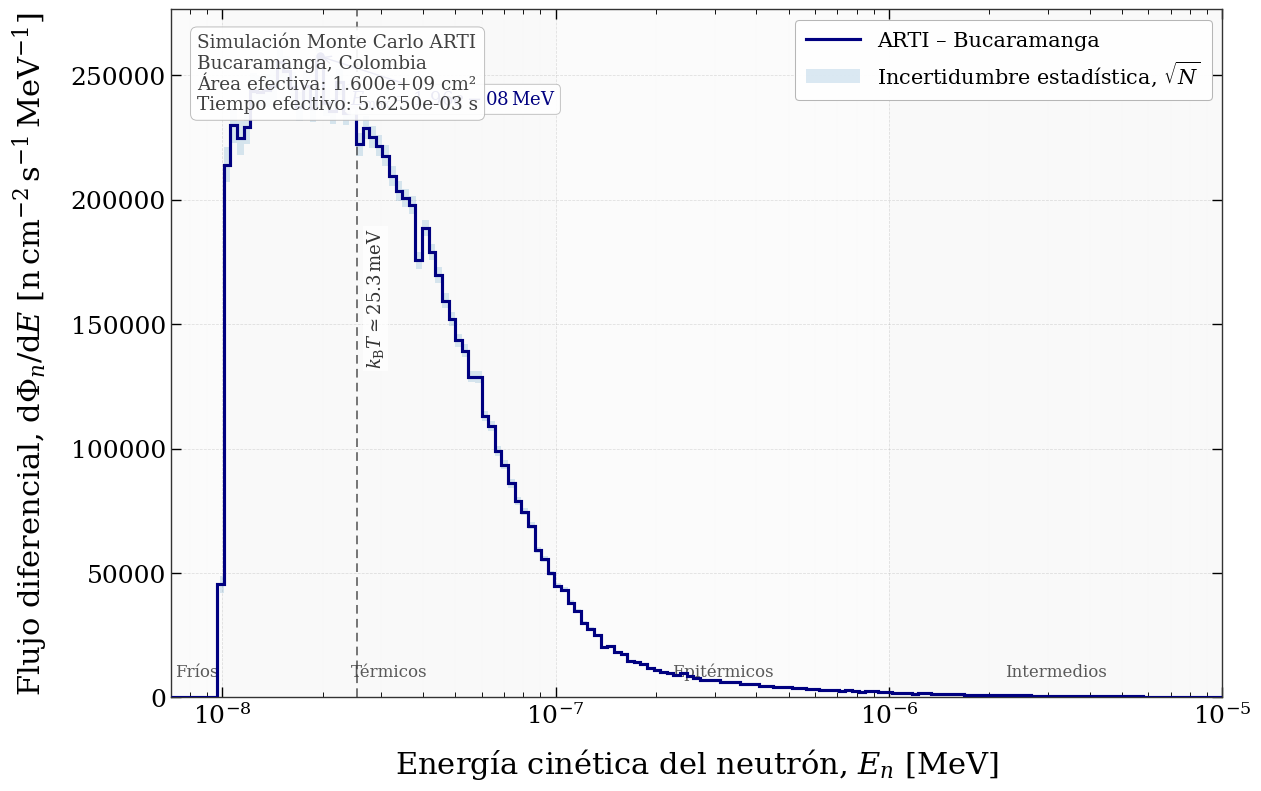

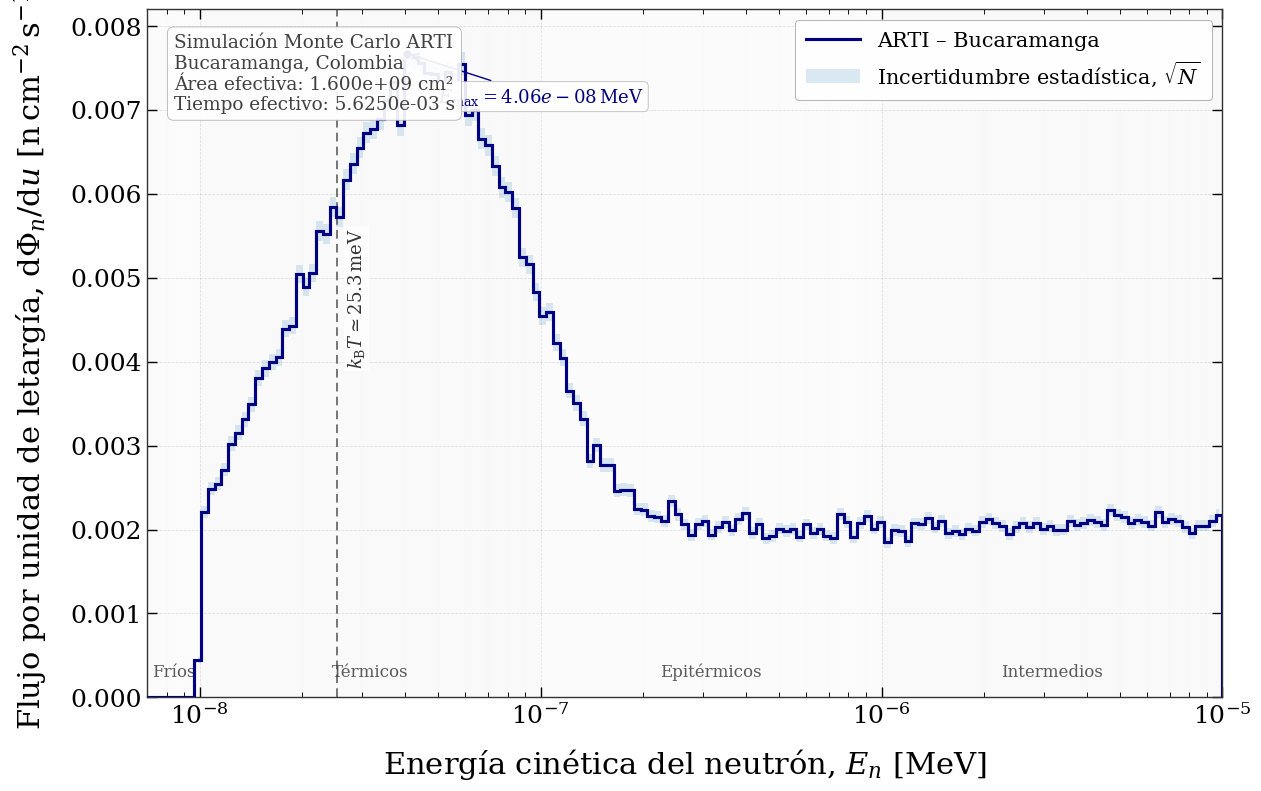


Figuras generadas correctamente.
--------------------------------
Directorio de salida: /media/ubuntu/TOSHIBA EXT/Tesis-doctorado-julio-2026-portatil/Simulaciones-Jaime-2024/Flujo-termico-suelo-seco/Graficas-flujo-neutrones-Bucaramanga

Flujo diferencial:
Graficas-flujo-neutrones-Bucaramanga/Flujo-diferencial-neutrones-Bucaramanga.pdf
Graficas-flujo-neutrones-Bucaramanga/Flujo-diferencial-neutrones-Bucaramanga.png

Flujo por unidad de letargía:
Graficas-flujo-neutrones-Bucaramanga/Flujo-letargico-neutrones-Bucaramanga.pdf
Graficas-flujo-neutrones-Bucaramanga/Flujo-letargico-neutrones-Bucaramanga.png

Resultados numéricos:
Graficas-flujo-neutrones-Bucaramanga/Espectros-diferencial-y-letargico-Bucaramanga.txt

Área efectiva: 1.600000e+09 cm²

ARTI – Bucaramanga
  Tiempo efectivo       = 5.625000e-03 s
  Neutrones totales     = 207,969
  Neutrones en intervalo = 207,967
  Diferencia relativa máxima entre dPhi/du y E·dPhi/dE = 8.697034e-05


In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


# ==========================================================
# CONFIGURACIÓN GENERAL
# ==========================================================

DIRECTORIO_SALIDA = "Graficas-flujo-neutrones-Bucaramanga"

os.makedirs(
    DIRECTORIO_SALIDA,
    exist_ok=True
)

ARCHIVO_DIFERENCIAL_PDF = os.path.join(
    DIRECTORIO_SALIDA,
    "Flujo-diferencial-neutrones-Bucaramanga.pdf"
)

ARCHIVO_DIFERENCIAL_PNG = os.path.join(
    DIRECTORIO_SALIDA,
    "Flujo-diferencial-neutrones-Bucaramanga.png"
)

ARCHIVO_LETARGICO_PDF = os.path.join(
    DIRECTORIO_SALIDA,
    "Flujo-letargico-neutrones-Bucaramanga.pdf"
)

ARCHIVO_LETARGICO_PNG = os.path.join(
    DIRECTORIO_SALIDA,
    "Flujo-letargico-neutrones-Bucaramanga.png"
)

ARCHIVO_RESULTADOS = os.path.join(
    DIRECTORIO_SALIDA,
    "Espectros-diferencial-y-letargico-Bucaramanga.txt"
)


# ==========================================================
# ARCHIVOS DE ENTRADA
# ==========================================================

FILES = [
    "filtered_neutrons.shw"
]

LABELS = [
    "ARTI – Bucaramanga"
]


# ==========================================================
# ÁREA Y TIEMPO EFECTIVOS
# ==========================================================
#
# Debes comprobar que estas expresiones coincidan exactamente
# con la normalización física utilizada en ARTI.
# ==========================================================

AREA_CM2 = (40000.0)**2

TIEMPO_MCG_S = (
    0.25 * 3600.0
    / (400.0**2)
)

TIMES = [
    TIEMPO_MCG_S
]


# ==========================================================
# PARÁMETROS FÍSICOS
# ==========================================================

MASA_NEUTRON_MEV = 939.5654205

# Cambia a "GeV/c" si px, py y pz están en GeV/c.
UNIDAD_MOMENTO = "MeV/c"

ID_NEUTRON_CORSIKA = 13


# ==========================================================
# INTERVALO ENERGÉTICO
# ==========================================================

ENERGIA_MIN_MEV = 7.0e-9
ENERGIA_MAX_MEV = 1.0e-5

NUMERO_BINS = 159

# Energía térmica característica a temperatura ambiente:
# 25.3 meV = 2.53e-8 MeV
ENERGIA_TERMICA_MEV = 2.53e-8


# ==========================================================
# OPCIONES VISUALES
# ==========================================================

MOSTRAR_REGIONES = True
MOSTRAR_REFERENCIA_TERMICA = True
MOSTRAR_INCERTIDUMBRE = True
MOSTRAR_MAXIMO = True

COLOR_CURVA = "navy"


# ==========================================================
# REGIONES ENERGÉTICAS
# ==========================================================

REGIONES_ENERGIA = [
    {
        "nombre": "Fríos",
        "emin": 2.0e-9,
        "emax": 1.0e-8
    },
    {
        "nombre": "Térmicos",
        "emin": 1.0e-8,
        "emax": 1.0e-7
    },
    {
        "nombre": "Epitérmicos",
        "emin": 1.0e-7,
        "emax": 1.0e-6
    },
    {
        "nombre": "Intermedios",
        "emin": 1.0e-6,
        "emax": 1.0e-5
    }
]


# ==========================================================
# TIPOGRAFÍA
# ==========================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",

    "font.size": 16,
    "axes.labelsize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 15,

    "axes.linewidth": 1.0,

    # Fuentes editables en PDF.
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})


# ==========================================================
# COLUMNAS DEL ARCHIVO ARTI/CORSIKA
# ==========================================================

COLUMNAS = [
    "particle",
    "px",
    "py",
    "pz",
    "x",
    "y",
    "z",
    "shower_id",
    "prm_id",
    "prm_energy",
    "prm_theta",
    "prm_phi"
]


# ==========================================================
# LEER ARCHIVO
# ==========================================================

def leer_archivo_particulas(nombre_archivo):

    if not os.path.exists(nombre_archivo):

        raise FileNotFoundError(
            f"No se encontró el archivo: {nombre_archivo}"
        )

    datos = pd.read_csv(
        nombre_archivo,
        sep=r"\s+",
        comment="#",
        header=None,
        on_bad_lines="skip"
    )

    if datos.shape[1] < len(COLUMNAS):

        raise ValueError(
            f"El archivo {nombre_archivo} contiene "
            f"{datos.shape[1]} columnas, pero se esperaban "
            f"al menos {len(COLUMNAS)}."
        )

    datos = datos.iloc[
        :,
        :len(COLUMNAS)
    ].copy()

    datos.columns = COLUMNAS

    return datos


# ==========================================================
# SELECCIONAR NEUTRONES
# ==========================================================

def seleccionar_neutrones(datos):

    columna_texto = (
        datos["particle"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    mascara_texto = columna_texto.isin([
        "neutron",
        "neutrons",
        "n"
    ])

    columna_numerica = pd.to_numeric(
        datos["particle"],
        errors="coerce"
    )

    mascara_numerica = (
        columna_numerica
        == ID_NEUTRON_CORSIKA
    )

    neutrones = datos[
        mascara_texto
        | mascara_numerica
    ].copy()

    if neutrones.empty:

        raise ValueError(
            "No se encontraron neutrones. Revisa la columna "
            "'particle' y el identificador utilizado."
        )

    return neutrones


# ==========================================================
# CALCULAR ENERGÍA CINÉTICA RELATIVISTA
# ==========================================================

def calcular_energia_cinetica(neutrones):

    for componente in [
        "px",
        "py",
        "pz"
    ]:

        neutrones[componente] = pd.to_numeric(
            neutrones[componente],
            errors="coerce"
        )

    neutrones = neutrones.dropna(
        subset=[
            "px",
            "py",
            "pz"
        ]
    ).copy()

    px = neutrones["px"].to_numpy(
        dtype=float
    )

    py = neutrones["py"].to_numpy(
        dtype=float
    )

    pz = neutrones["pz"].to_numpy(
        dtype=float
    )

    momento = np.sqrt(
        px**2
        + py**2
        + pz**2
    )

    if UNIDAD_MOMENTO == "GeV/c":

        momento_MeV_c = (
            momento * 1000.0
        )

    elif UNIDAD_MOMENTO == "MeV/c":

        momento_MeV_c = momento

    else:

        raise ValueError(
            "UNIDAD_MOMENTO debe ser "
            "'MeV/c' o 'GeV/c'."
        )

    energia_total_MeV = np.sqrt(
        momento_MeV_c**2
        + MASA_NEUTRON_MEV**2
    )

    energia_cinetica_MeV = (
        energia_total_MeV
        - MASA_NEUTRON_MEV
    )

    neutrones["momento_MeV_c"] = (
        momento_MeV_c
    )

    neutrones["energia_cinetica_MeV"] = (
        energia_cinetica_MeV
    )

    neutrones = neutrones[
        np.isfinite(
            neutrones["energia_cinetica_MeV"]
        )
        & (
            neutrones["energia_cinetica_MeV"] > 0
        )
    ].copy()

    return neutrones


# ==========================================================
# BINS LOGARÍTMICOS COMUNES
# ==========================================================

BORDES_ENERGIA_MEV = np.logspace(
    np.log10(ENERGIA_MIN_MEV),
    np.log10(ENERGIA_MAX_MEV),
    NUMERO_BINS + 1
)

# Centro geométrico, apropiado para bins logarítmicos.
CENTROS_ENERGIA_MEV = np.sqrt(
    BORDES_ENERGIA_MEV[:-1]
    * BORDES_ENERGIA_MEV[1:]
)

ANCHOS_ENERGIA_MEV = np.diff(
    BORDES_ENERGIA_MEV
)

# Ancho en letargía de cada grupo.
ANCHOS_LETARGIA = np.log(
    BORDES_ENERGIA_MEV[1:]
    / BORDES_ENERGIA_MEV[:-1]
)


# ==========================================================
# AÑADIR REGIONES ENERGÉTICAS
# ==========================================================

def agregar_regiones_energeticas(ax):

    if not MOSTRAR_REGIONES:
        return

    for indice, region in enumerate(
        REGIONES_ENERGIA
    ):

        xmin = max(
            region["emin"],
            ENERGIA_MIN_MEV
        )

        xmax = min(
            region["emax"],
            ENERGIA_MAX_MEV
        )

        if xmin >= xmax:
            continue

        # Tonalidades grises alternadas.
        alpha_region = (
            0.045
            if indice % 2 == 0
            else 0.075
        )

        ax.axvspan(
            xmin,
            xmax,
            facecolor="0.70",
            alpha=alpha_region,
            linewidth=0,
            zorder=0
        )

        centro = np.sqrt(
            xmin * xmax
        )

        ax.text(
            centro,
            0.025,
            region["nombre"],
            transform=ax.get_xaxis_transform(),
            fontsize=12,
            ha="center",
            va="bottom",
            color="0.35",
            zorder=2
        )


# ==========================================================
# AÑADIR REFERENCIA TÉRMICA
# ==========================================================

def agregar_referencia_termica(ax):

    if not MOSTRAR_REFERENCIA_TERMICA:
        return

    ax.axvline(
        ENERGIA_TERMICA_MEV,
        color="0.25",
        linestyle=(0, (5, 3)),
        linewidth=1.25,
        alpha=0.80,
        zorder=5
    )

    ax.text(
        ENERGIA_TERMICA_MEV * 1.06,
        0.58,
        r"$k_{\mathrm{B}}T\simeq25.3\,\mathrm{meV}$",
        transform=ax.get_xaxis_transform(),
        fontsize=13,
        color="0.20",
        rotation=90,
        ha="left",
        va="center",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
            pad=1.5
        ),
        zorder=10
    )


# ==========================================================
# FORMATO COMÚN DE LAS FIGURAS
# ==========================================================

def aplicar_formato_comun(
    fig,
    ax,
    ylabel,
    etiqueta_simulacion
):

    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    ax.set_xscale("log")

    ax.set_xlim(
        ENERGIA_MIN_MEV,
        ENERGIA_MAX_MEV
    )

    ax.set_xlabel(
        r"Energía cinética del neutrón, "
        r"$E_n$ [MeV]",
        labelpad=13
    )

    ax.set_ylabel(
        ylabel,
        labelpad=15
    )

    ax.xaxis.set_major_locator(
        ticker.LogLocator(
            base=10,
            numticks=8
        )
    )

    ax.xaxis.set_minor_locator(
        ticker.LogLocator(
            base=10,
            subs=np.arange(2, 10) * 0.1,
            numticks=100
        )
    )

    ax.xaxis.set_major_formatter(
        ticker.LogFormatterMathtext(
            base=10
        )
    )

    ax.xaxis.set_minor_formatter(
        ticker.NullFormatter()
    )

    ax.tick_params(
        axis="both",
        which="major",
        direction="in",
        length=7,
        width=1.0,
        labelsize=18,
        top=True,
        right=True
    )

    ax.tick_params(
        axis="both",
        which="minor",
        direction="in",
        length=3.5,
        width=0.65,
        top=True,
        right=True
    )

    ax.grid(
        visible=True,
        which="major",
        axis="both",
        linestyle="--",
        linewidth=0.55,
        color="0.50",
        alpha=0.24
    )

    ax.grid(
        visible=True,
        which="minor",
        axis="x",
        linestyle=":",
        linewidth=0.30,
        color="0.60",
        alpha=0.07
    )

    ax.set_axisbelow(True)

    agregar_regiones_energeticas(
        ax
    )

    agregar_referencia_termica(
        ax
    )

    ax.text(
        0.025,
        0.965,
        etiqueta_simulacion,
        transform=ax.transAxes,
        fontsize=13.3,
        ha="left",
        va="top",
        color="0.25",
        bbox=dict(
            facecolor="white",
            edgecolor="0.70",
            linewidth=0.65,
            boxstyle="round,pad=0.35",
            alpha=0.92
        ),
        zorder=15
    )

    for spine in ax.spines.values():

        spine.set_linewidth(1.0)
        spine.set_color("0.20")


# ==========================================================
# MARCAR EL MÁXIMO
# ==========================================================

def marcar_maximo(
    ax,
    valores,
    color
):

    indices_validos = np.where(
        np.isfinite(valores)
        & (valores > 0)
    )[0]

    if (
        not MOSTRAR_MAXIMO
        or indices_validos.size == 0
    ):
        return

    indice_maximo = int(
        np.nanargmax(valores)
    )

    energia_maximo = (
        CENTROS_ENERGIA_MEV[
            indice_maximo
        ]
    )

    valor_maximo = valores[
        indice_maximo
    ]

    ax.plot(
        energia_maximo,
        valor_maximo,
        marker="o",
        markersize=7,
        markerfacecolor=color,
        markeredgecolor="white",
        markeredgewidth=0.9,
        linestyle="none",
        zorder=9
    )

    ax.annotate(
        r"$E_{\max}="
        f"{energia_maximo:.2e}"
        r"\,\mathrm{MeV}$",
        xy=(
            energia_maximo,
            valor_maximo
        ),
        xytext=(
            22,
            -35
        ),
        textcoords="offset points",
        fontsize=13,
        color=color,
        arrowprops=dict(
            arrowstyle="->",
            linewidth=1.0,
            color=color
        ),
        bbox=dict(
            facecolor="white",
            edgecolor="0.70",
            linewidth=0.6,
            alpha=0.90,
            boxstyle="round,pad=0.25"
        ),
        zorder=12
    )


# ==========================================================
# FUNCIÓN PRINCIPAL
# ==========================================================

def neutron_flux(
    files,
    times,
    labels,
    area_cm2
):

    if not (
        len(files)
        == len(times)
        == len(labels)
    ):

        raise ValueError(
            "FILES, TIMES y LABELS deben tener "
            "la misma longitud."
        )

    if area_cm2 <= 0:

        raise ValueError(
            "El área efectiva debe ser positiva."
        )

    # Figura 1: flujo diferencial.
    fig_diff, ax_diff = plt.subplots(
        figsize=(12.5, 7.8),
        constrained_layout=True
    )

    # Figura 2: flujo por unidad de letargía.
    fig_leth, ax_leth = plt.subplots(
        figsize=(12.5, 7.8),
        constrained_layout=True
    )

    resultados = []

    for indice, nombre_archivo in enumerate(
        files
    ):

        tiempo_s = float(
            times[indice]
        )

        etiqueta = labels[indice]

        if tiempo_s <= 0:

            raise ValueError(
                f"El tiempo de {nombre_archivo} "
                "debe ser positivo."
            )

        # --------------------------------------------------
        # LEER Y PROCESAR
        # --------------------------------------------------

        datos = leer_archivo_particulas(
            nombre_archivo
        )

        neutrones = seleccionar_neutrones(
            datos
        )

        neutrones = calcular_energia_cinetica(
            neutrones
        )

        energia_MeV = (
            neutrones["energia_cinetica_MeV"]
            .to_numpy(dtype=float)
        )

        mascara_intervalo = (
            (energia_MeV >= ENERGIA_MIN_MEV)
            & (energia_MeV <= ENERGIA_MAX_MEV)
        )

        energia_filtrada_MeV = energia_MeV[
            mascara_intervalo
        ]

        if energia_filtrada_MeV.size == 0:

            raise ValueError(
                f"No existen neutrones en el intervalo "
                f"{ENERGIA_MIN_MEV:.3e}–"
                f"{ENERGIA_MAX_MEV:.3e} MeV."
            )

        # --------------------------------------------------
        # HISTOGRAMA
        # --------------------------------------------------

        cuentas, _ = np.histogram(
            energia_filtrada_MeV,
            bins=BORDES_ENERGIA_MEV
        )

        cuentas = cuentas.astype(float)

        # --------------------------------------------------
        # FLUJO DIFERENCIAL
        # --------------------------------------------------
        #
        # dPhi/dE = N / (A t DeltaE)
        #
        # Unidades:
        # n cm^-2 s^-1 MeV^-1
        # --------------------------------------------------

        flujo_diferencial = (
            cuentas
            / (
                area_cm2
                * tiempo_s
                * ANCHOS_ENERGIA_MEV
            )
        )

        incertidumbre_diferencial = (
            np.sqrt(cuentas)
            / (
                area_cm2
                * tiempo_s
                * ANCHOS_ENERGIA_MEV
            )
        )

        # --------------------------------------------------
        # FLUJO POR UNIDAD DE LETARGÍA
        # --------------------------------------------------
        #
        # dPhi/du = N / (A t Delta_u)
        #
        # Unidades:
        # n cm^-2 s^-1
        # --------------------------------------------------

        flujo_letargico = (
            cuentas
            / (
                area_cm2
                * tiempo_s
                * ANCHOS_LETARGIA
            )
        )

        incertidumbre_letargica = (
            np.sqrt(cuentas)
            / (
                area_cm2
                * tiempo_s
                * ANCHOS_LETARGIA
            )
        )

        # --------------------------------------------------
        # COMPROBACIÓN:
        # dPhi/du ≈ E dPhi/dE
        # --------------------------------------------------

        flujo_letargico_desde_diferencial = (
            CENTROS_ENERGIA_MEV
            * flujo_diferencial
        )

        diferencia_relativa = np.full_like(
            flujo_letargico,
            np.nan,
            dtype=float
        )

        mascara_flujo = (
            flujo_letargico > 0
        )

        diferencia_relativa[
            mascara_flujo
        ] = np.abs(
            flujo_letargico[
                mascara_flujo
            ]
            - flujo_letargico_desde_diferencial[
                mascara_flujo
            ]
        ) / flujo_letargico[
            mascara_flujo
        ]

        # --------------------------------------------------
        # VALORES PARA GRAFICAR
        # --------------------------------------------------

        flujo_diff_visible = np.where(
            flujo_diferencial > 0,
            flujo_diferencial,
            np.nan
        )

        flujo_leth_visible = np.where(
            flujo_letargico > 0,
            flujo_letargico,
            np.nan
        )

        diff_inferior = np.where(
            flujo_diferencial
            - incertidumbre_diferencial
            > 0,
            flujo_diferencial
            - incertidumbre_diferencial,
            np.nan
        )

        diff_superior = np.where(
            flujo_diferencial > 0,
            flujo_diferencial
            + incertidumbre_diferencial,
            np.nan
        )

        leth_inferior = np.where(
            flujo_letargico
            - incertidumbre_letargica
            > 0,
            flujo_letargico
            - incertidumbre_letargica,
            np.nan
        )

        leth_superior = np.where(
            flujo_letargico > 0,
            flujo_letargico
            + incertidumbre_letargica,
            np.nan
        )

        # --------------------------------------------------
        # FIGURA DEL FLUJO DIFERENCIAL
        # --------------------------------------------------

        ax_diff.stairs(
            flujo_diferencial,
            BORDES_ENERGIA_MEV,
            color=COLOR_CURVA,
            linewidth=2.25,
            label=etiqueta,
            zorder=6
        )

        if MOSTRAR_INCERTIDUMBRE:

            ax_diff.fill_between(
                CENTROS_ENERGIA_MEV,
                diff_inferior,
                diff_superior,
                step="mid",
                alpha=0.16,
                linewidth=0,
                zorder=3,
                label=r"Incertidumbre estadística, $\sqrt{N}$"
            )

        marcar_maximo(
            ax_diff,
            flujo_diff_visible,
            COLOR_CURVA
        )

        # --------------------------------------------------
        # FIGURA DEL FLUJO LETÁRGICO
        # --------------------------------------------------

        ax_leth.stairs(
            flujo_letargico,
            BORDES_ENERGIA_MEV,
            color=COLOR_CURVA,
            linewidth=2.25,
            label=etiqueta,
            zorder=6
        )

        if MOSTRAR_INCERTIDUMBRE:

            ax_leth.fill_between(
                CENTROS_ENERGIA_MEV,
                leth_inferior,
                leth_superior,
                step="mid",
                alpha=0.16,
                linewidth=0,
                zorder=3,
                label=r"Incertidumbre estadística, $\sqrt{N}$"
            )

        marcar_maximo(
            ax_leth,
            flujo_leth_visible,
            COLOR_CURVA
        )

        resultados.append({
            "archivo": nombre_archivo,
            "etiqueta": etiqueta,
            "tiempo_s": tiempo_s,
            "neutrones_totales": len(neutrones),
            "neutrones_intervalo": len(
                energia_filtrada_MeV
            ),
            "cuentas": cuentas,
            "flujo_diferencial": flujo_diferencial,
            "incertidumbre_diferencial":
                incertidumbre_diferencial,
            "flujo_letargico": flujo_letargico,
            "incertidumbre_letargica":
                incertidumbre_letargica,
            "flujo_letargico_desde_diferencial":
                flujo_letargico_desde_diferencial,
            "diferencia_relativa":
                diferencia_relativa
        })

    # ======================================================
    # FORMATO DEL FLUJO DIFERENCIAL
    # ======================================================

    texto_simulacion = (
        "Simulación Monte Carlo ARTI\n"
        "Bucaramanga, Colombia\n"
        f"Área efectiva: {area_cm2:.3e} cm²\n"
        f"Tiempo efectivo: {times[0]:.4e} s"
    )

    aplicar_formato_comun(
        fig=fig_diff,
        ax=ax_diff,
        ylabel=(
            r"Flujo diferencial, "
            r"$\mathrm{d}\Phi_n/\mathrm{d}E$ "
            r"[$\mathrm{n}\,\mathrm{cm}^{-2}\,"
            r"\mathrm{s}^{-1}\,\mathrm{MeV}^{-1}$]"
        ),
        etiqueta_simulacion=texto_simulacion
    )

    leyenda_diff = ax_diff.legend(
        loc="upper right",
        fontsize=15,
        frameon=True,
        framealpha=0.95,
        facecolor="white",
        edgecolor="0.70",
        borderpad=0.55,
        labelspacing=0.42,
        handlelength=2.6
    )

    leyenda_diff.get_frame().set_linewidth(
        0.75
    )

    # ======================================================
    # FORMATO DEL FLUJO LETÁRGICO
    # ======================================================

    aplicar_formato_comun(
        fig=fig_leth,
        ax=ax_leth,
        ylabel=(
            r"Flujo por unidad de letargía, "
            r"$\mathrm{d}\Phi_n/\mathrm{d}u$ "
            r"[$\mathrm{n}\,\mathrm{cm}^{-2}\,"
            r"\mathrm{s}^{-1}$]"
        ),
        etiqueta_simulacion=texto_simulacion
    )

    leyenda_leth = ax_leth.legend(
        loc="upper right",
        fontsize=15,
        frameon=True,
        framealpha=0.95,
        facecolor="white",
        edgecolor="0.70",
        borderpad=0.55,
        labelspacing=0.42,
        handlelength=2.6
    )

    leyenda_leth.get_frame().set_linewidth(
        0.75
    )

    # ======================================================
    # GUARDAR ARCHIVO NUMÉRICO
    # ======================================================

    with open(
        ARCHIVO_RESULTADOS,
        "w",
        encoding="utf-8"
    ) as archivo:

        archivo.write(
            "# Espectros diferencial y por unidad de letargía\n"
        )

        archivo.write(
            "# dPhi/dE = N/(A t DeltaE)\n"
        )

        archivo.write(
            "# dPhi/du = N/(A t Delta_u)\n"
        )

        archivo.write(
            "# Delta_u = ln(E_max/E_min)\n"
        )

        archivo.write(
            "# dPhi/du aproximadamente igual a "
            "E_centro dPhi/dE\n"
        )

        archivo.write(
            f"# Área efectiva = "
            f"{area_cm2:.10e} cm^2\n"
        )

        archivo.write(
            f"# Número de bins = {NUMERO_BINS}\n"
        )

        archivo.write("#\n")

        for resultado in resultados:

            archivo.write(
                f"# Archivo: "
                f"{resultado['archivo']}\n"
            )

            archivo.write(
                f"# Etiqueta: "
                f"{resultado['etiqueta']}\n"
            )

            archivo.write(
                f"# Tiempo efectivo: "
                f"{resultado['tiempo_s']:.10e} s\n"
            )

            archivo.write(
                f"# Neutrones totales: "
                f"{resultado['neutrones_totales']}\n"
            )

            archivo.write(
                f"# Neutrones en intervalo: "
                f"{resultado['neutrones_intervalo']}\n"
            )

            archivo.write(
                "# E_min_MeV\t"
                "E_max_MeV\t"
                "E_centro_MeV\t"
                "DeltaE_MeV\t"
                "Delta_u\t"
                "Cuentas\t"
                "dPhi_dE_n_cm-2_s-1_MeV-1\t"
                "Sigma_dPhi_dE\t"
                "dPhi_du_n_cm-2_s-1\t"
                "Sigma_dPhi_du\t"
                "E_dPhi_dE_n_cm-2_s-1\t"
                "Diferencia_relativa\n"
            )

            for j in range(
                NUMERO_BINS
            ):

                diferencia = (
                    resultado[
                        "diferencia_relativa"
                    ][j]
                )

                archivo.write(
                    f"{BORDES_ENERGIA_MEV[j]:.10e}\t"
                    f"{BORDES_ENERGIA_MEV[j + 1]:.10e}\t"
                    f"{CENTROS_ENERGIA_MEV[j]:.10e}\t"
                    f"{ANCHOS_ENERGIA_MEV[j]:.10e}\t"
                    f"{ANCHOS_LETARGIA[j]:.10e}\t"
                    f"{int(resultado['cuentas'][j])}\t"
                    f"{resultado['flujo_diferencial'][j]:.10e}\t"
                    f"{resultado['incertidumbre_diferencial'][j]:.10e}\t"
                    f"{resultado['flujo_letargico'][j]:.10e}\t"
                    f"{resultado['incertidumbre_letargica'][j]:.10e}\t"
                    f"{resultado['flujo_letargico_desde_diferencial'][j]:.10e}\t"
                    f"{diferencia:.10e}\n"
                )

            archivo.write("\n")

    # ======================================================
    # GUARDAR AMBAS FIGURAS
    # ======================================================

    fig_diff.savefig(
        ARCHIVO_DIFERENCIAL_PDF,
        format="pdf",
        bbox_inches="tight",
        pad_inches=0.05,
        facecolor="white"
    )

    fig_diff.savefig(
        ARCHIVO_DIFERENCIAL_PNG,
        format="png",
        dpi=600,
        bbox_inches="tight",
        pad_inches=0.05,
        facecolor="white"
    )

    fig_leth.savefig(
        ARCHIVO_LETARGICO_PDF,
        format="pdf",
        bbox_inches="tight",
        pad_inches=0.05,
        facecolor="white"
    )

    fig_leth.savefig(
        ARCHIVO_LETARGICO_PNG,
        format="png",
        dpi=600,
        bbox_inches="tight",
        pad_inches=0.05,
        facecolor="white"
    )

    plt.show()

    plt.close(fig_diff)
    plt.close(fig_leth)

    # ======================================================
    # INFORMACIÓN EN TERMINAL
    # ======================================================

    print("\nFiguras generadas correctamente.")
    print("--------------------------------")

    print(
        f"Directorio de salida: "
        f"{os.path.abspath(DIRECTORIO_SALIDA)}"
    )

    print("\nFlujo diferencial:")
    print(ARCHIVO_DIFERENCIAL_PDF)
    print(ARCHIVO_DIFERENCIAL_PNG)

    print("\nFlujo por unidad de letargía:")
    print(ARCHIVO_LETARGICO_PDF)
    print(ARCHIVO_LETARGICO_PNG)

    print("\nResultados numéricos:")
    print(ARCHIVO_RESULTADOS)

    print(
        f"\nÁrea efectiva: "
        f"{area_cm2:.6e} cm²"
    )

    for resultado in resultados:

        diferencias_validas = (
            resultado["diferencia_relativa"][
                np.isfinite(
                    resultado["diferencia_relativa"]
                )
            ]
        )

        if diferencias_validas.size > 0:

            diferencia_maxima = np.max(
                diferencias_validas
            )

        else:

            diferencia_maxima = np.nan

        print(
            f"\n{resultado['etiqueta']}"
        )

        print(
            f"  Tiempo efectivo       = "
            f"{resultado['tiempo_s']:.6e} s"
        )

        print(
            f"  Neutrones totales     = "
            f"{resultado['neutrones_totales']:,}"
        )

        print(
            f"  Neutrones en intervalo = "
            f"{resultado['neutrones_intervalo']:,}"
        )

        print(
            "  Diferencia relativa máxima entre "
            "dPhi/du y E·dPhi/dE = "
            f"{diferencia_maxima:.6e}"
        )


# ==========================================================
# EJECUTAR
# ==========================================================

neutron_flux(
    files=FILES,
    times=TIMES,
    labels=LABELS,
    area_cm2=AREA_CM2
)

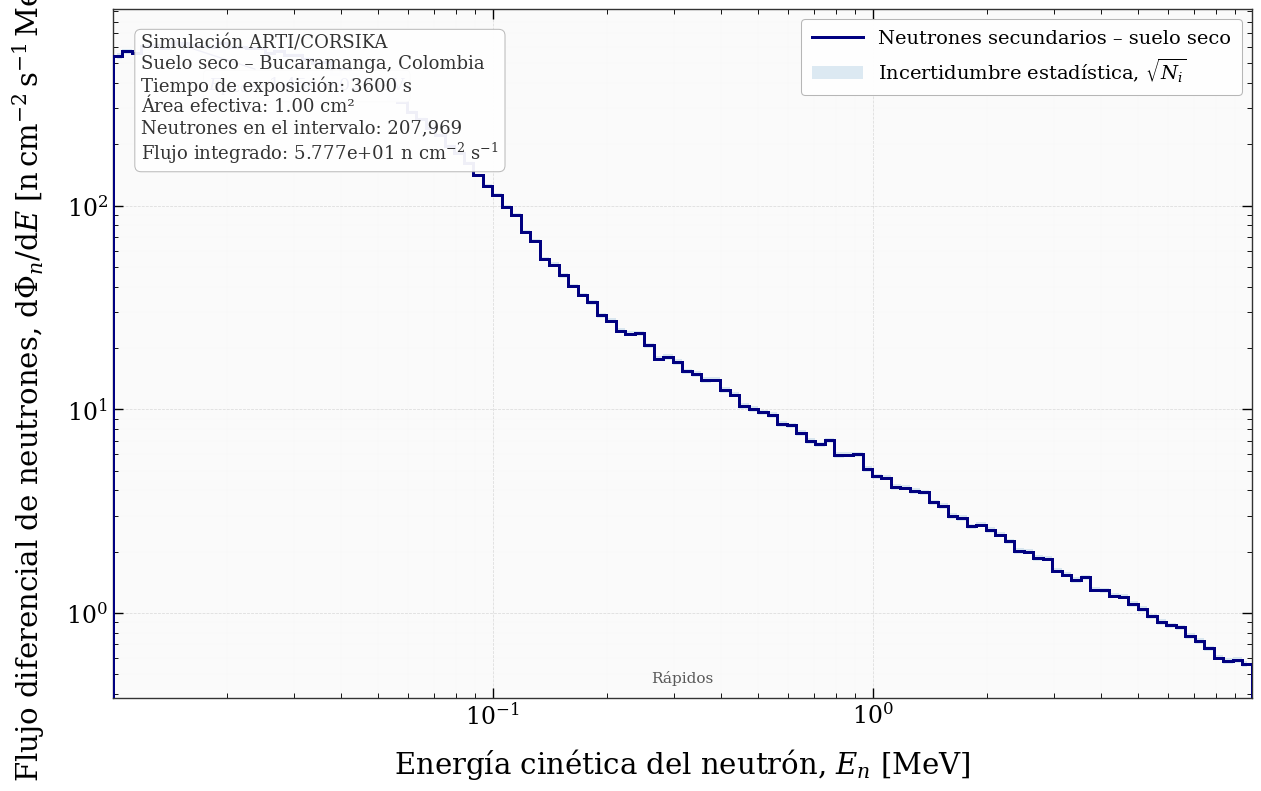

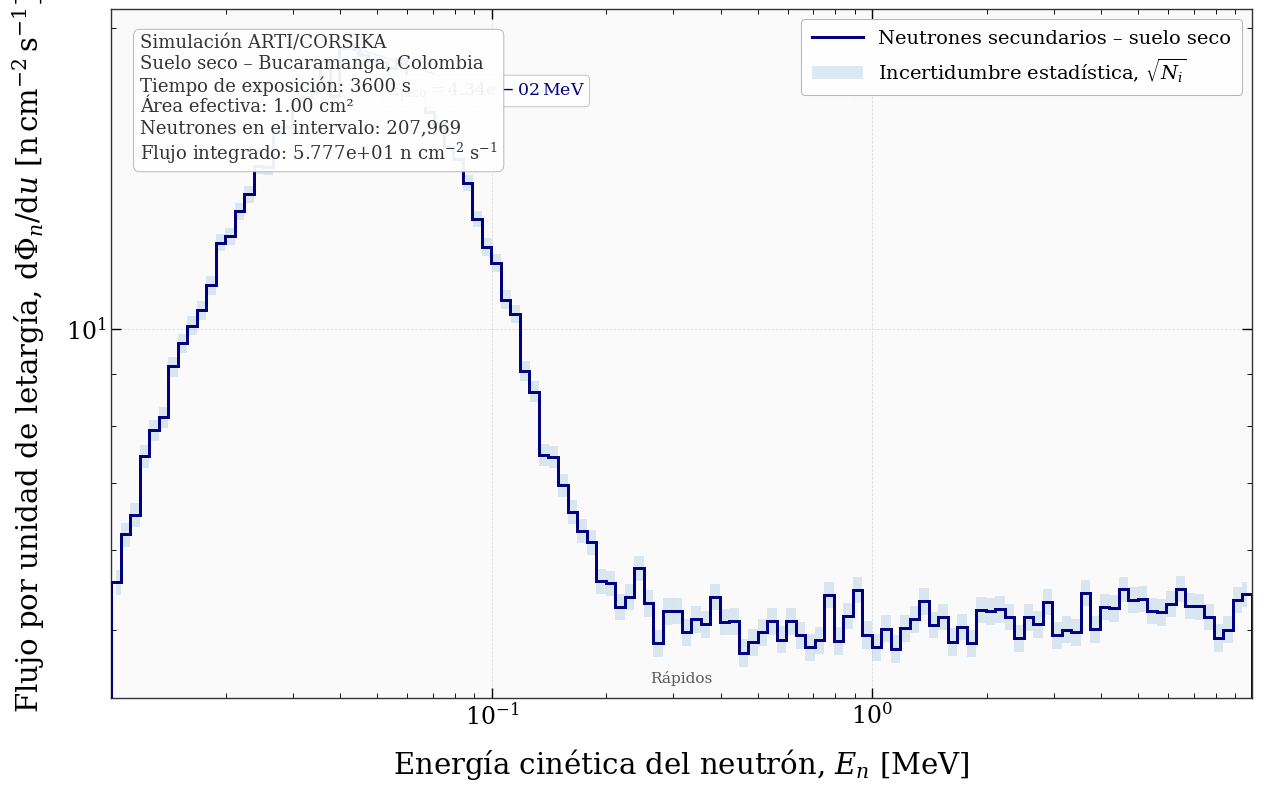


ANÁLISIS DEL FLUJO DE NEUTRONES

Origen considerado:
Suelo seco – Bucaramanga, Colombia

Archivo de entrada:
/media/ubuntu/TOSHIBA EXT/Tesis-doctorado-julio-2026-portatil/Simulaciones-Jaime-2024/Flujo-termico-suelo-seco/filtered_neutrons.shw

Unidad del momento: GeV/c
Masa del neutrón: 939.5654205 MeV/c²

Tiempo de exposición: 3.600000e+03 s
Lado de la superficie: 1.000000e+00 cm
Área efectiva: 1.000000e+00 cm²

Neutrones totales del archivo: 207,969
Neutrones dentro del intervalo: 207,969

Energía mínima representada: 1.0001076932e-02 MeV
Energía máxima representada: 9.9475172837e+00 MeV

Fluencia en el intervalo: 2.0796900000e+05 n cm^-2
Flujo integrado: 5.7769166667e+01 n cm^-2 s^-1

Comprobaciones:
Integral del flujo diferencial: 5.7768888889e+01 n cm^-2 s^-1
Integral del flujo letárgico: 5.7768888889e+01 n cm^-2 s^-1

ARCHIVOS GENERADOS
Flujo diferencial PDF:
/media/ubuntu/TOSHIBA EXT/Tesis-doctorado-julio-2026-portatil/Simulaciones-Jaime-2024/Flujo-termico-suelo-seco/Graficas-fl

In [10]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


# ==========================================================
# CONFIGURACIÓN GENERAL
# ==========================================================

ARCHIVO_ENTRADA = Path("filtered_neutrons.shw")

DIRECTORIO_SALIDA = Path(
    "Graficas-flujo-neutrones-Bucaramanga"
)

DIRECTORIO_SALIDA.mkdir(
    parents=True,
    exist_ok=True
)


# ==========================================================
# NORMALIZACIÓN FÍSICA
# ==========================================================
#
# Superficie cuadrada de 1 cm de lado:
#
# A = (1 cm)^2 = 1 cm^2
#
# El archivo completo representa una exposición de 3600 s.
# ==========================================================

LADO_SUPERFICIE_CM = 1.0

AREA_CM2 = LADO_SUPERFICIE_CM**2

TIEMPO_EXPOSICION_S = 3600.0


# ==========================================================
# PARÁMETROS FÍSICOS
# ==========================================================

ID_NEUTRON_CORSIKA = 13

MASA_NEUTRON_MEV = 939.5654205

# En los archivos ARTI/CORSIKA, las componentes del momento
# suelen almacenarse en GeV/c.
UNIDAD_MOMENTO = "GeV/c"


# ==========================================================
# CONFIGURACIÓN DEL INTERVALO ENERGÉTICO
# ==========================================================
#
# OPCIÓN RECOMENDADA:
# usar todo el intervalo energético presente en el archivo.
#
# Si deseas restringir manualmente el espectro, reemplaza
# None por valores expresados en MeV.
#
# Ejemplo para el intervalo térmico/epitérmico:
#
# ENERGIA_MIN_MEV = 7.0e-9
# ENERGIA_MAX_MEV = 1.0e-5
# ==========================================================

ENERGIA_MIN_MEV = None
ENERGIA_MAX_MEV = None

NUMERO_BINS = 120

ENERGIA_TERMICA_MEV = 2.53e-8


# ==========================================================
# OPCIONES VISUALES
# ==========================================================

MOSTRAR_INCERTIDUMBRE = True
MOSTRAR_MAXIMO = True

# Solo se mostrarán regiones térmicas cuando estén dentro
# del intervalo energético realmente graficado.
MOSTRAR_REGIONES = True
MOSTRAR_REFERENCIA_TERMICA = True

COLOR_CURVA = "navy"


# ==========================================================
# ARCHIVOS DE SALIDA
# ==========================================================

ARCHIVO_DIFERENCIAL_PDF = (
    DIRECTORIO_SALIDA
    / "Flujo-diferencial-neutrones-Bucaramanga.pdf"
)

ARCHIVO_DIFERENCIAL_PNG = (
    DIRECTORIO_SALIDA
    / "Flujo-diferencial-neutrones-Bucaramanga.png"
)

ARCHIVO_LETARGICO_PDF = (
    DIRECTORIO_SALIDA
    / "Flujo-letargico-neutrones-Bucaramanga.pdf"
)

ARCHIVO_LETARGICO_PNG = (
    DIRECTORIO_SALIDA
    / "Flujo-letargico-neutrones-Bucaramanga.png"
)

ARCHIVO_ESPECTROS_CSV = (
    DIRECTORIO_SALIDA
    / "Espectros-diferencial-y-letargico-Bucaramanga.csv"
)

ARCHIVO_RESUMEN_TXT = (
    DIRECTORIO_SALIDA
    / "Resumen-flujo-neutrones-Bucaramanga.txt"
)


# ==========================================================
# REGIONES ENERGÉTICAS
# ==========================================================

REGIONES_ENERGIA = [
    {
        "nombre": "Ultrafríos",
        "emin": 1.0e-12,
        "emax": 2.0e-9
    },
    {
        "nombre": "Fríos",
        "emin": 2.0e-9,
        "emax": 1.0e-8
    },
    {
        "nombre": "Térmicos",
        "emin": 1.0e-8,
        "emax": 1.0e-7
    },
    {
        "nombre": "Epitérmicos",
        "emin": 1.0e-7,
        "emax": 1.0e-6
    },
    {
        "nombre": "Intermedios",
        "emin": 1.0e-6,
        "emax": 1.0e-2
    },
    {
        "nombre": "Rápidos",
        "emin": 1.0e-2,
        "emax": 20.0
    },
    {
        "nombre": "Alta energía",
        "emin": 20.0,
        "emax": 1.0e8
    }
]


# ==========================================================
# COLUMNAS DEL ARCHIVO
# ==========================================================

COLUMNAS = [
    "particle",
    "px",
    "py",
    "pz",
    "x",
    "y",
    "z",
    "shower_id",
    "prm_id",
    "prm_energy",
    "prm_theta",
    "prm_phi"
]


# ==========================================================
# TIPOGRAFÍA
# ==========================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",

    "font.size": 16,
    "axes.labelsize": 21,
    "xtick.labelsize": 17,
    "ytick.labelsize": 17,
    "legend.fontsize": 14,

    "axes.linewidth": 1.0,

    # Mantiene las fuentes editables en PDF.
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})


# ==========================================================
# LECTURA DEL ARCHIVO
# ==========================================================

def leer_archivo_particulas(nombre_archivo):
    """
    Lee el archivo ARTI/CORSIKA y asigna los nombres de columnas.
    """

    if not nombre_archivo.exists():
        raise FileNotFoundError(
            f"No se encontró el archivo:\n"
            f"{nombre_archivo.resolve()}"
        )

    datos = pd.read_csv(
        nombre_archivo,
        sep=r"\s+",
        comment="#",
        header=None,
        on_bad_lines="skip"
    )

    if datos.shape[1] < len(COLUMNAS):
        raise ValueError(
            f"El archivo contiene {datos.shape[1]} columnas, "
            f"pero se esperaban al menos {len(COLUMNAS)}."
        )

    # Se utilizan únicamente las primeras 12 columnas.
    datos = datos.iloc[
        :,
        :len(COLUMNAS)
    ].copy()

    datos.columns = COLUMNAS

    return datos


# ==========================================================
# SELECCIÓN DE NEUTRONES
# ==========================================================

def seleccionar_neutrones(datos):
    """
    Selecciona neutrones escritos como texto o mediante
    el identificador numérico CORSIKA 13.
    """

    columna_texto = (
        datos["particle"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    mascara_texto = columna_texto.isin([
        "neutron",
        "neutrons",
        "n"
    ])

    columna_numerica = pd.to_numeric(
        datos["particle"],
        errors="coerce"
    )

    mascara_numerica = (
        columna_numerica
        == ID_NEUTRON_CORSIKA
    )

    neutrones = datos[
        mascara_texto | mascara_numerica
    ].copy()

    if neutrones.empty:
        raise ValueError(
            "No se encontraron neutrones en el archivo. "
            "Revisa el identificador de la partícula."
        )

    return neutrones


# ==========================================================
# ENERGÍA CINÉTICA RELATIVISTA
# ==========================================================

def calcular_energia_cinetica(neutrones):
    """
    Calcula el momento y la energía cinética relativista:

        E_k = sqrt(p^2 + m_n^2) - m_n

    utilizando unidades naturales c = 1.
    """

    componentes = [
        "px",
        "py",
        "pz"
    ]

    for componente in componentes:
        neutrones[componente] = pd.to_numeric(
            neutrones[componente],
            errors="coerce"
        )

    neutrones = neutrones.dropna(
        subset=componentes
    ).copy()

    px = neutrones["px"].to_numpy(
        dtype=float
    )

    py = neutrones["py"].to_numpy(
        dtype=float
    )

    pz = neutrones["pz"].to_numpy(
        dtype=float
    )

    momento_archivo = np.sqrt(
        px**2
        + py**2
        + pz**2
    )

    if UNIDAD_MOMENTO == "GeV/c":
        momento_MeV_c = (
            momento_archivo
            * 1000.0
        )

    elif UNIDAD_MOMENTO == "MeV/c":
        momento_MeV_c = momento_archivo

    else:
        raise ValueError(
            "UNIDAD_MOMENTO debe ser "
            "'GeV/c' o 'MeV/c'."
        )

    energia_total_MeV = np.sqrt(
        momento_MeV_c**2
        + MASA_NEUTRON_MEV**2
    )

    energia_cinetica_MeV = (
        energia_total_MeV
        - MASA_NEUTRON_MEV
    )

    neutrones["momento_MeV_c"] = (
        momento_MeV_c
    )

    neutrones["energia_cinetica_MeV"] = (
        energia_cinetica_MeV
    )

    mascara_valida = (
        np.isfinite(
            neutrones["energia_cinetica_MeV"]
        )
        & (
            neutrones["energia_cinetica_MeV"]
            > 0.0
        )
    )

    neutrones = neutrones[
        mascara_valida
    ].copy()

    if neutrones.empty:
        raise ValueError(
            "No fue posible calcular energías cinéticas "
            "positivas y finitas."
        )

    return neutrones


# ==========================================================
# INTERVALO ENERGÉTICO
# ==========================================================

def determinar_intervalo_energia(energias):
    """
    Determina el intervalo de energía usando los valores
    definidos por el usuario o el rango presente en los datos.
    """

    energia_minima_datos = float(
        np.min(energias)
    )

    energia_maxima_datos = float(
        np.max(energias)
    )

    if ENERGIA_MIN_MEV is None:
        energia_minima = energia_minima_datos
    else:
        energia_minima = float(
            ENERGIA_MIN_MEV
        )

    if ENERGIA_MAX_MEV is None:
        energia_maxima = energia_maxima_datos
    else:
        energia_maxima = float(
            ENERGIA_MAX_MEV
        )

    if energia_minima <= 0:
        raise ValueError(
            "La energía mínima debe ser positiva."
        )

    if energia_maxima <= energia_minima:
        raise ValueError(
            "La energía máxima debe ser mayor "
            "que la energía mínima."
        )

    return energia_minima, energia_maxima


# ==========================================================
# REGIONES ENERGÉTICAS
# ==========================================================

def agregar_regiones_energeticas(
    ax,
    energia_minima,
    energia_maxima
):
    """
    Añade regiones energéticas únicamente cuando se encuentran
    dentro del intervalo visible.
    """

    if not MOSTRAR_REGIONES:
        return

    for indice, region in enumerate(
        REGIONES_ENERGIA
    ):
        xmin = max(
            region["emin"],
            energia_minima
        )

        xmax = min(
            region["emax"],
            energia_maxima
        )

        if xmin >= xmax:
            continue

        alpha_region = (
            0.035
            if indice % 2 == 0
            else 0.060
        )

        ax.axvspan(
            xmin,
            xmax,
            facecolor="0.70",
            alpha=alpha_region,
            linewidth=0,
            zorder=0
        )

        centro_region = np.sqrt(
            xmin * xmax
        )

        ax.text(
            centro_region,
            0.018,
            region["nombre"],
            transform=ax.get_xaxis_transform(),
            fontsize=11,
            ha="center",
            va="bottom",
            color="0.35",
            zorder=2
        )


# ==========================================================
# REFERENCIA DE ENERGÍA TÉRMICA
# ==========================================================

def agregar_referencia_termica(
    ax,
    energia_minima,
    energia_maxima
):
    """
    Dibuja la energía térmica característica solamente cuando
    se encuentra dentro del intervalo representado.
    """

    if not MOSTRAR_REFERENCIA_TERMICA:
        return

    if not (
        energia_minima
        <= ENERGIA_TERMICA_MEV
        <= energia_maxima
    ):
        return

    ax.axvline(
        ENERGIA_TERMICA_MEV,
        color="0.25",
        linestyle=(0, (5, 3)),
        linewidth=1.2,
        alpha=0.80,
        zorder=5
    )

    ax.text(
        ENERGIA_TERMICA_MEV * 1.08,
        0.58,
        r"$k_{\mathrm{B}}T"
        r"\simeq25.3\,\mathrm{meV}$",
        transform=ax.get_xaxis_transform(),
        fontsize=12,
        color="0.20",
        rotation=90,
        ha="left",
        va="center",
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.80,
            "pad": 1.5
        },
        zorder=10
    )


# ==========================================================
# FORMATO COMÚN
# ==========================================================

def aplicar_formato_comun(
    fig,
    ax,
    ylabel,
    texto_simulacion,
    energia_minima,
    energia_maxima
):
    """
    Aplica formato científico uniforme a las dos figuras.
    """

    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlim(
        energia_minima,
        energia_maxima
    )

    ax.set_xlabel(
        r"Energía cinética del neutrón, "
        r"$E_n$ [MeV]",
        labelpad=12
    )

    ax.set_ylabel(
        ylabel,
        labelpad=14
    )

    ax.xaxis.set_major_locator(
        ticker.LogLocator(
            base=10,
            numticks=12
        )
    )

    ax.xaxis.set_minor_locator(
        ticker.LogLocator(
            base=10,
            subs=np.arange(2, 10) * 0.1,
            numticks=100
        )
    )

    ax.yaxis.set_major_locator(
        ticker.LogLocator(
            base=10,
            numticks=12
        )
    )

    ax.xaxis.set_major_formatter(
        ticker.LogFormatterMathtext(
            base=10
        )
    )

    ax.yaxis.set_major_formatter(
        ticker.LogFormatterMathtext(
            base=10
        )
    )

    ax.xaxis.set_minor_formatter(
        ticker.NullFormatter()
    )

    ax.yaxis.set_minor_formatter(
        ticker.NullFormatter()
    )

    ax.tick_params(
        axis="both",
        which="major",
        direction="in",
        length=7,
        width=1.0,
        top=True,
        right=True
    )

    ax.tick_params(
        axis="both",
        which="minor",
        direction="in",
        length=3.5,
        width=0.65,
        top=True,
        right=True
    )

    ax.grid(
        visible=True,
        which="major",
        axis="both",
        linestyle="--",
        linewidth=0.55,
        color="0.50",
        alpha=0.25
    )

    ax.grid(
        visible=True,
        which="minor",
        axis="both",
        linestyle=":",
        linewidth=0.30,
        color="0.60",
        alpha=0.08
    )

    ax.set_axisbelow(True)

    agregar_regiones_energeticas(
        ax,
        energia_minima,
        energia_maxima
    )

    agregar_referencia_termica(
        ax,
        energia_minima,
        energia_maxima
    )

    ax.text(
        0.025,
        0.965,
        texto_simulacion,
        transform=ax.transAxes,
        fontsize=13,
        ha="left",
        va="top",
        color="0.20",
        bbox={
            "facecolor": "white",
            "edgecolor": "0.70",
            "linewidth": 0.7,
            "boxstyle": "round,pad=0.35",
            "alpha": 0.94
        },
        zorder=15
    )

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)
        spine.set_color("0.20")


# ==========================================================
# MARCAR EL MÁXIMO
# ==========================================================

def marcar_maximo(
    ax,
    centros,
    valores
):
    """
    Identifica y marca el máximo del espectro.
    """

    if not MOSTRAR_MAXIMO:
        return

    mascara = (
        np.isfinite(valores)
        & (valores > 0.0)
    )

    if not np.any(mascara):
        return

    indices_validos = np.where(
        mascara
    )[0]

    indice_maximo_local = np.argmax(
        valores[mascara]
    )

    indice_maximo = indices_validos[
        indice_maximo_local
    ]

    energia_maximo = centros[
        indice_maximo
    ]

    valor_maximo = valores[
        indice_maximo
    ]

    ax.plot(
        energia_maximo,
        valor_maximo,
        marker="o",
        markersize=6.5,
        markerfacecolor=COLOR_CURVA,
        markeredgecolor="white",
        markeredgewidth=0.9,
        linestyle="none",
        zorder=10
    )

    ax.annotate(
        r"$E_{\mathrm{pico}}="
        f"{energia_maximo:.2e}"
        r"\,\mathrm{MeV}$",
        xy=(
            energia_maximo,
            valor_maximo
        ),
        xytext=(
            24,
            -34
        ),
        textcoords="offset points",
        fontsize=12.5,
        color=COLOR_CURVA,
        arrowprops={
            "arrowstyle": "->",
            "linewidth": 1.0,
            "color": COLOR_CURVA
        },
        bbox={
            "facecolor": "white",
            "edgecolor": "0.70",
            "linewidth": 0.6,
            "alpha": 0.92,
            "boxstyle": "round,pad=0.25"
        },
        zorder=12
    )


# ==========================================================
# CREACIÓN DE UNA FIGURA
# ==========================================================

def crear_figura_espectro(
    bordes,
    centros,
    valores,
    incertidumbre,
    ylabel,
    texto_simulacion,
    energia_minima,
    energia_maxima,
    etiqueta,
    archivo_pdf,
    archivo_png
):
    """
    Genera y guarda una figura espectral.
    """

    fig, ax = plt.subplots(
        figsize=(12.5, 7.8),
        constrained_layout=True
    )

    ax.stairs(
        valores,
        bordes,
        color=COLOR_CURVA,
        linewidth=2.15,
        label=etiqueta,
        zorder=6
    )

    if MOSTRAR_INCERTIDUMBRE:
        limite_inferior = np.where(
            valores - incertidumbre > 0.0,
            valores - incertidumbre,
            np.nan
        )

        limite_superior = np.where(
            valores > 0.0,
            valores + incertidumbre,
            np.nan
        )

        ax.fill_between(
            centros,
            limite_inferior,
            limite_superior,
            step="mid",
            alpha=0.15,
            linewidth=0,
            zorder=3,
            label=r"Incertidumbre estadística, $\sqrt{N_i}$"
        )

    marcar_maximo(
        ax,
        centros,
        valores
    )

    aplicar_formato_comun(
        fig=fig,
        ax=ax,
        ylabel=ylabel,
        texto_simulacion=texto_simulacion,
        energia_minima=energia_minima,
        energia_maxima=energia_maxima
    )

    leyenda = ax.legend(
        loc="upper right",
        frameon=True,
        framealpha=0.95,
        facecolor="white",
        edgecolor="0.70",
        borderpad=0.55,
        labelspacing=0.42,
        handlelength=2.6
    )

    leyenda.get_frame().set_linewidth(
        0.75
    )

    fig.savefig(
        archivo_pdf,
        format="pdf",
        bbox_inches="tight",
        pad_inches=0.05,
        facecolor="white"
    )

    fig.savefig(
        archivo_png,
        format="png",
        dpi=600,
        bbox_inches="tight",
        pad_inches=0.05,
        facecolor="white"
    )

    plt.show()
    plt.close(fig)


# ==========================================================
# PROGRAMA PRINCIPAL
# ==========================================================

def main():
    """
    Lee el archivo, calcula los espectros y genera las figuras.
    """

    # ------------------------------------------------------
    # Lectura y selección
    # ------------------------------------------------------

    datos = leer_archivo_particulas(
        ARCHIVO_ENTRADA
    )

    neutrones = seleccionar_neutrones(
        datos
    )

    neutrones = calcular_energia_cinetica(
        neutrones
    )

    energias_MeV = (
        neutrones["energia_cinetica_MeV"]
        .to_numpy(dtype=float)
    )

    numero_neutrones_total = len(
        energias_MeV
    )

    # ------------------------------------------------------
    # Intervalo energético
    # ------------------------------------------------------

    energia_minima, energia_maxima = (
        determinar_intervalo_energia(
            energias_MeV
        )
    )

    mascara_intervalo = (
        (energias_MeV >= energia_minima)
        & (energias_MeV <= energia_maxima)
    )

    energias_filtradas = energias_MeV[
        mascara_intervalo
    ]

    numero_neutrones_intervalo = len(
        energias_filtradas
    )

    if numero_neutrones_intervalo == 0:
        raise ValueError(
            "No existen neutrones dentro del intervalo "
            "energético seleccionado."
        )

    # ------------------------------------------------------
    # Bins logarítmicos
    # ------------------------------------------------------

    bordes = np.logspace(
        np.log10(energia_minima),
        np.log10(energia_maxima),
        NUMERO_BINS + 1
    )

    centros = np.sqrt(
        bordes[:-1]
        * bordes[1:]
    )

    anchos_energia = np.diff(
        bordes
    )

    anchos_letargia = np.log(
        bordes[1:]
        / bordes[:-1]
    )

    cuentas, _ = np.histogram(
        energias_filtradas,
        bins=bordes
    )

    cuentas = cuentas.astype(
        float
    )

    # ------------------------------------------------------
    # Flujo diferencial
    # ------------------------------------------------------
    #
    # dPhi/dE = N_i / (A t DeltaE_i)
    #
    # Unidades:
    # n cm^-2 s^-1 MeV^-1
    # ------------------------------------------------------

    flujo_diferencial = (
        cuentas
        / (
            AREA_CM2
            * TIEMPO_EXPOSICION_S
            * anchos_energia
        )
    )

    incertidumbre_diferencial = (
        np.sqrt(cuentas)
        / (
            AREA_CM2
            * TIEMPO_EXPOSICION_S
            * anchos_energia
        )
    )

    # ------------------------------------------------------
    # Flujo por unidad de letargía
    # ------------------------------------------------------
    #
    # dPhi/du = N_i / (A t Delta u_i)
    #
    # Unidades:
    # n cm^-2 s^-1
    # ------------------------------------------------------

    flujo_letargico = (
        cuentas
        / (
            AREA_CM2
            * TIEMPO_EXPOSICION_S
            * anchos_letargia
        )
    )

    incertidumbre_letargica = (
        np.sqrt(cuentas)
        / (
            AREA_CM2
            * TIEMPO_EXPOSICION_S
            * anchos_letargia
        )
    )

    # ------------------------------------------------------
    # Magnitudes integradas
    # ------------------------------------------------------

    fluencia_intervalo = (
        numero_neutrones_intervalo
        / AREA_CM2
    )

    flujo_integrado_intervalo = (
        numero_neutrones_intervalo
        / (
            AREA_CM2
            * TIEMPO_EXPOSICION_S
        )
    )

    # Comprobación numérica del flujo diferencial.
    flujo_integrado_desde_espectro = np.sum(
        flujo_diferencial
        * anchos_energia
    )

    flujo_integrado_desde_letargia = np.sum(
        flujo_letargico
        * anchos_letargia
    )

    # ------------------------------------------------------
    # Texto dentro de las figuras
    # ------------------------------------------------------

    texto_simulacion = (
        "Simulación ARTI/CORSIKA\n"
        "Suelo seco – Bucaramanga, Colombia\n"
        f"Tiempo de exposición: "
        f"{TIEMPO_EXPOSICION_S:.0f} s\n"
        f"Área efectiva: {AREA_CM2:.2f} cm²\n"
        f"Neutrones en el intervalo: "
        f"{numero_neutrones_intervalo:,}\n"
        f"Flujo integrado: "
        f"{flujo_integrado_intervalo:.3e} "
        r"n cm$^{-2}$ s$^{-1}$"
    )

    etiqueta = (
        "Neutrones secundarios – suelo seco"
    )

    # ------------------------------------------------------
    # Figura del flujo diferencial
    # ------------------------------------------------------

    crear_figura_espectro(
        bordes=bordes,
        centros=centros,
        valores=flujo_diferencial,
        incertidumbre=incertidumbre_diferencial,
        ylabel=(
            r"Flujo diferencial de neutrones, "
            r"$\mathrm{d}\Phi_n/\mathrm{d}E$ "
            r"[$\mathrm{n\,cm^{-2}\,s^{-1}\,MeV^{-1}}$]"
        ),
        texto_simulacion=texto_simulacion,
        energia_minima=energia_minima,
        energia_maxima=energia_maxima,
        etiqueta=etiqueta,
        archivo_pdf=ARCHIVO_DIFERENCIAL_PDF,
        archivo_png=ARCHIVO_DIFERENCIAL_PNG
    )

    # ------------------------------------------------------
    # Figura del flujo por unidad de letargía
    # ------------------------------------------------------

    crear_figura_espectro(
        bordes=bordes,
        centros=centros,
        valores=flujo_letargico,
        incertidumbre=incertidumbre_letargica,
        ylabel=(
            r"Flujo por unidad de letargía, "
            r"$\mathrm{d}\Phi_n/\mathrm{d}u$ "
            r"[$\mathrm{n\,cm^{-2}\,s^{-1}}$]"
        ),
        texto_simulacion=texto_simulacion,
        energia_minima=energia_minima,
        energia_maxima=energia_maxima,
        etiqueta=etiqueta,
        archivo_pdf=ARCHIVO_LETARGICO_PDF,
        archivo_png=ARCHIVO_LETARGICO_PNG
    )

    # ------------------------------------------------------
    # Tabla numérica
    # ------------------------------------------------------

    tabla_resultados = pd.DataFrame({
        "E_min_MeV": bordes[:-1],
        "E_max_MeV": bordes[1:],
        "E_centro_MeV": centros,
        "Delta_E_MeV": anchos_energia,
        "Delta_u": anchos_letargia,
        "cuentas": cuentas.astype(int),

        "dPhi_dE_n_cm-2_s-1_MeV-1":
            flujo_diferencial,

        "sigma_dPhi_dE":
            incertidumbre_diferencial,

        "dPhi_du_n_cm-2_s-1":
            flujo_letargico,

        "sigma_dPhi_du":
            incertidumbre_letargica
    })

    tabla_resultados.to_csv(
        ARCHIVO_ESPECTROS_CSV,
        index=False,
        float_format="%.10e"
    )

    # ------------------------------------------------------
    # Resumen
    # ------------------------------------------------------

    resumen = (
        "ANÁLISIS DEL FLUJO DE NEUTRONES\n"
        "========================================\n\n"

        "Origen considerado:\n"
        "Suelo seco – Bucaramanga, Colombia\n\n"

        f"Archivo de entrada:\n"
        f"{ARCHIVO_ENTRADA.resolve()}\n\n"

        f"Unidad del momento: {UNIDAD_MOMENTO}\n"
        f"Masa del neutrón: "
        f"{MASA_NEUTRON_MEV:.7f} MeV/c²\n\n"

        f"Tiempo de exposición: "
        f"{TIEMPO_EXPOSICION_S:.6e} s\n"

        f"Lado de la superficie: "
        f"{LADO_SUPERFICIE_CM:.6e} cm\n"

        f"Área efectiva: "
        f"{AREA_CM2:.6e} cm²\n\n"

        f"Neutrones totales del archivo: "
        f"{numero_neutrones_total:,}\n"

        f"Neutrones dentro del intervalo: "
        f"{numero_neutrones_intervalo:,}\n\n"

        f"Energía mínima representada: "
        f"{energia_minima:.10e} MeV\n"

        f"Energía máxima representada: "
        f"{energia_maxima:.10e} MeV\n\n"

        f"Fluencia en el intervalo: "
        f"{fluencia_intervalo:.10e} n cm^-2\n"

        f"Flujo integrado: "
        f"{flujo_integrado_intervalo:.10e} "
        f"n cm^-2 s^-1\n\n"

        "Comprobaciones:\n"

        f"Integral del flujo diferencial: "
        f"{flujo_integrado_desde_espectro:.10e} "
        f"n cm^-2 s^-1\n"

        f"Integral del flujo letárgico: "
        f"{flujo_integrado_desde_letargia:.10e} "
        f"n cm^-2 s^-1\n"
    )

    with open(
        ARCHIVO_RESUMEN_TXT,
        "w",
        encoding="utf-8"
    ) as archivo:
        archivo.write(
            resumen
        )

    # ------------------------------------------------------
    # Salida en terminal
    # ------------------------------------------------------

    print("\n" + resumen)

    print("ARCHIVOS GENERADOS")
    print("========================================")

    print(
        f"Flujo diferencial PDF:\n"
        f"{ARCHIVO_DIFERENCIAL_PDF.resolve()}"
    )

    print(
        f"\nFlujo diferencial PNG:\n"
        f"{ARCHIVO_DIFERENCIAL_PNG.resolve()}"
    )

    print(
        f"\nFlujo letárgico PDF:\n"
        f"{ARCHIVO_LETARGICO_PDF.resolve()}"
    )

    print(
        f"\nFlujo letárgico PNG:\n"
        f"{ARCHIVO_LETARGICO_PNG.resolve()}"
    )

    print(
        f"\nTabla numérica:\n"
        f"{ARCHIVO_ESPECTROS_CSV.resolve()}"
    )

    print(
        f"\nResumen:\n"
        f"{ARCHIVO_RESUMEN_TXT.resolve()}"
    )


# ==========================================================
# EJECUCIÓN
# ==========================================================

if __name__ == "__main__":
    main()

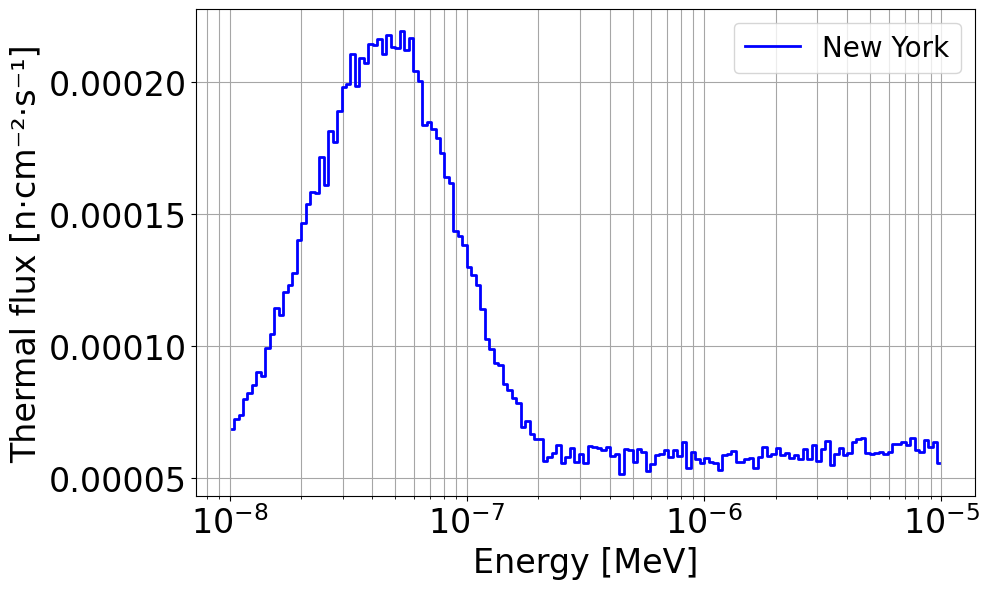

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Definir área de detección (cm²) y tiempos de integración (s)
A = (40000)**2  # Área en cm²
time_default = 12 * 3600 / (400**2)  # Tiempo por defecto en segundos
time_mcg = (1/4) * 3600 / (400**2)  # Tiempo específico para (1 hora en segundos, ajusta según necesites)

# Lista de archivos de entrada y sus tiempos correspondientes
#input_file1 = "all_neutron_yny_SAN11.shw"
input_file2 = "filtered_neutrons_ync.shw"
files = [input_file2]
times = [time_mcg]  # Lista de tiempos para cada archivo
labels = ["New York"]

# Función para procesar los archivos y graficar solo el flujo letárgico
def neutron_flux(files, times, output_pdf_name, A):
    """
    Procesa múltiples archivos de flujos de neutrones y grafica solo el flujo letárgico.
    
    :param files: Lista de archivos de entrada.
    :param times: Lista de tiempos de integración (s) para cada archivo.
    :param output_pdf_name: Nombre del archivo de salida para la gráfica.
    :param A: Área de detección (cm²).
    """
    m = 939.6  # Masa del neutrón en MeV/c^2
    plt.figure(figsize=(10, 6))  # Crear figura
    colors = ['b', 'r', 'g', 'm', 'c', 'y', 'k']  # Colores para diferenciar curvas
    
    for i, file in enumerate(files):
        # Usar el tiempo correspondiente a este archivo
        time = times[i]
        
        # Leer el archivo CSV con formato adecuado
        df = pd.read_csv(file, delimiter=" ", skiprows=1, skipinitialspace=True, comment="#", on_bad_lines='skip')
        df.columns = ["particle", "px", "py", "pz", "x", "y", "z", "shower_id", "prm_id", "prm_energy", "prm_theta", "prm_phi"]
        
        # Filtrar solo los neutrones
        df_neutrons = df[df["particle"] == "neutron"].copy()
        
        # Calcular la energía cinética (Ek) usando la fórmula Ek = (p² / 2m)
        df_neutrons["Ek"] = (df_neutrons["px"]**2 + df_neutrons["py"]**2 + df_neutrons["pz"]**2) / (2 * m)
        
        # Filtrar energías válidas (Ek < 1573 MeV y Ek != 0)
        df_neutrons = df_neutrons[(df_neutrons["Ek"] < 1573.0) & (df_neutrons["Ek"] != 0)]
        neu_Ek = np.array(df_neutrons["Ek"])
        
        # Definir bins logarítmicos para energía
        min_Ek, max_Ek = np.min(neu_Ek), np.max(neu_Ek)
        num_bins = 159
        bins_Ek = np.logspace(np.log10(min_Ek), np.log10(max_Ek), num_bins + 1)
        
        # Calcular histograma de energía cinética
        y_diff, _ = np.histogram(neu_Ek, bins=bins_Ek, density=False)
        bin_centers = (bins_Ek[1:] + bins_Ek[:-1]) / 2  # Centros de los bins
        bin_widths = bins_Ek[1:] - bins_Ek[:-1]  # Ancho de los bins
        
        # Calcular flujo diferencial
        phi_diff = y_diff / (A * time * bin_centers)
        
        # Calcular flujo letárgico: φ_lethargy(u) = φ_diff(E) * E_mid
        phi_lethargy = phi_diff * bin_centers
        
        # Graficar flujo letárgico
        color = colors[i % len(colors)]  # Ciclar colores si hay más archivos
        plt.step(bin_centers, phi_lethargy, color=color, where='mid', label=f'{labels[i]}', linewidth=2)
    
    # Configuración de la gráfica
    plt.xscale('log')  # Escala logarítmica en el eje X
    plt.xlabel('Energy [MeV]', size=24)
    plt.ylabel('Thermal flux [n·cm⁻²·s⁻¹]', size=24)
    plt.title('', size=20)
    plt.grid(True, which="both", ls="-", color='0.65')
    #plt.legend()
    plt.legend(fontsize=20)
    plt.tick_params(labelsize=24)
    
    # Guardar la gráfica en un archivo
    plt.tight_layout()
    plt.savefig(output_pdf_name)
    # Guardar y mostrar
    plt.tight_layout()
    plt.savefig('Thermal-flux_NY.jpg', format='jpg')
    plt.savefig('Thermal-flux_NY.pdf', format='pdf')
    plt.show()

# Ejecutar la función con los archivos y tiempos especificados
output_name = "Thermal_flux_neutrons_NY.png"
neutron_flux(files, times, output_name, A)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


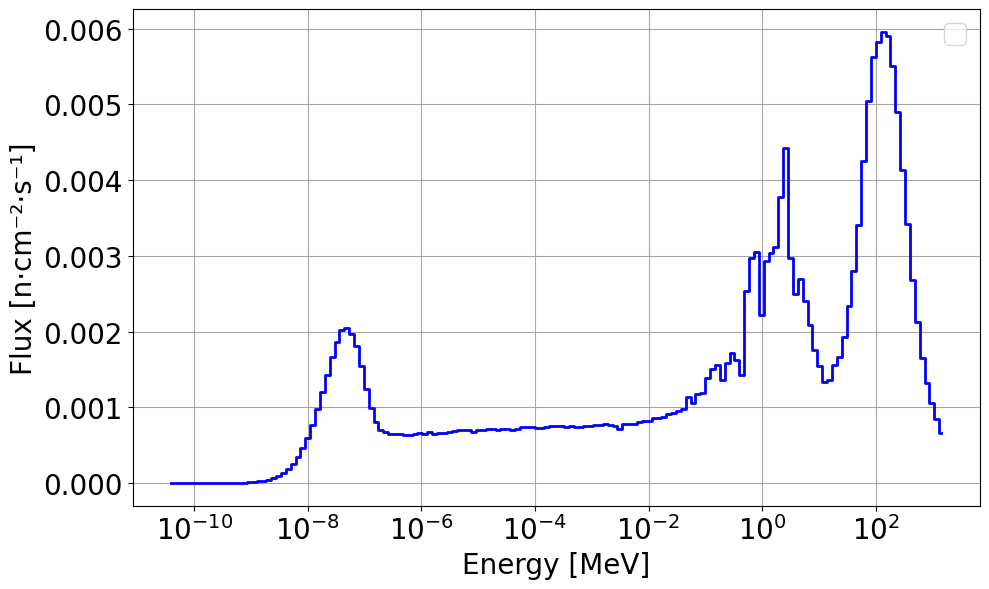

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Definir área de detección (cm²) y tiempos de integración (s)
A = (40000)**2  # Área en cm²
time_default = 12 * 3600 / (400**2)  # Tiempo por defecto en segundos
time_mcg = (1/4) * 3600 / (400**2)  # Tiempo específico para (1 hora en segundos, ajusta según necesites)

# Lista de archivos de entrada y sus tiempos correspondientes
#input_file1 = "all_neutron_yny_SAN11.shw"
input_file2 = "all_bga_neutron_35.shw"
files = [input_file2]
times = [time_mcg]  # Lista de tiempos para cada archivo
labels = [""]

# Función para procesar los archivos y graficar solo el flujo letárgico
def neutron_flux(files, times, output_pdf_name, A):
    """
    Procesa múltiples archivos de flujos de neutrones y grafica solo el flujo letárgico.
    
    :param files: Lista de archivos de entrada.
    :param times: Lista de tiempos de integración (s) para cada archivo.
    :param output_pdf_name: Nombre del archivo de salida para la gráfica.
    :param A: Área de detección (cm²).
    """
    m = 939.6  # Masa del neutrón en MeV/c^2
    plt.figure(figsize=(10, 6))  # Crear figura
    colors = ['b', 'r', 'g', 'm', 'c', 'y', 'k']  # Colores para diferenciar curvas
    
    for i, file in enumerate(files):
        # Usar el tiempo correspondiente a este archivo
        time = times[i]
        
        # Leer el archivo CSV con formato adecuado
        df = pd.read_csv(file, delimiter=" ", skiprows=1, skipinitialspace=True, comment="#", on_bad_lines='skip')
        df.columns = ["particle", "px", "py", "pz", "x", "y", "z", "shower_id", "prm_id", "prm_energy", "prm_theta", "prm_phi"]
        
        # Filtrar solo los neutrones
        df_neutrons = df[df["particle"] == "neutron"].copy()
        
        # Calcular la energía cinética (Ek) usando la fórmula Ek = (p² / 2m)
        df_neutrons["Ek"] = (df_neutrons["px"]**2 + df_neutrons["py"]**2 + df_neutrons["pz"]**2) / (2 * m)
        
        # Filtrar energías válidas (Ek < 1573 MeV y Ek != 0)
        df_neutrons = df_neutrons[(df_neutrons["Ek"] < 1573.0) & (df_neutrons["Ek"] != 0)]
        neu_Ek = np.array(df_neutrons["Ek"])
        
        # Definir bins logarítmicos para energía
        min_Ek, max_Ek = np.min(neu_Ek), np.max(neu_Ek)
        num_bins = 159
        bins_Ek = np.logspace(np.log10(min_Ek), np.log10(max_Ek), num_bins + 1)
        
        # Calcular histograma de energía cinética
        y_diff, _ = np.histogram(neu_Ek, bins=bins_Ek, density=False)
        bin_centers = (bins_Ek[1:] + bins_Ek[:-1]) / 2  # Centros de los bins
        bin_widths = bins_Ek[1:] - bins_Ek[:-1]  # Ancho de los bins
        
        # Calcular flujo diferencial
        phi_diff = y_diff / (A * time * bin_centers)
        
        # Calcular flujo letárgico: φ_lethargy(u) = φ_diff(E) * E_mid
        phi_lethargy = phi_diff * bin_centers
        
        # Graficar flujo letárgico
        color = colors[i % len(colors)]  # Ciclar colores si hay más archivos
        plt.step(bin_centers, phi_lethargy, color=color, where='mid', label=f'{labels[i]}', linewidth=2)
    
    # Configuración de la gráfica
    plt.xscale('log')  # Escala logarítmica en el eje X
    plt.xlabel('Energy [MeV]', size=20)
    #plt.ylabel('Flux [n·cm⁻²·s⁻¹]', size=20)
    plt.ylabel('Flux [n·cm⁻²·s⁻¹]', size=20)
    plt.title('', size=20)
    plt.grid(True, which="both", ls="-", color='0.65')
    #plt.legend()
    plt.legend(fontsize=20)
    plt.tick_params(labelsize=20)
    
    # Guardar la gráfica en un archivo
    plt.tight_layout()
    plt.savefig(output_pdf_name)
    # Guardar y mostrar
    plt.tight_layout()
    plt.savefig('Bucaramanga-flux-1.jpg', format='jpg')
    plt.savefig('Bucaramanga-flux-1.pdf', format='pdf')
    plt.show()

# Ejecutar la función con los archivos y tiempos especificados
output_name = "Thermal_flux_neutrons.png"
neutron_flux(files, times, output_name, A)


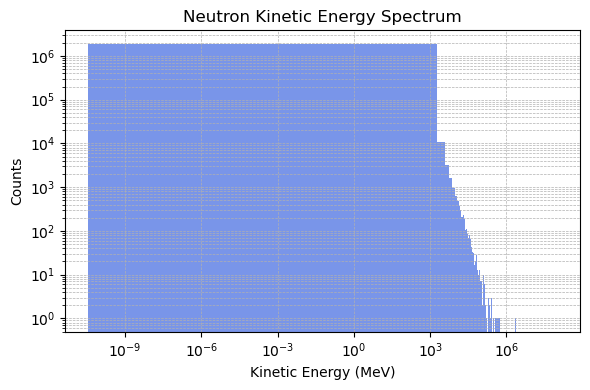

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Constantes
m_neutron_MeV = 939.565  # Masa del neutrón en MeV/c^2

# Cargar los datos
# Cambia 'datos.txt' por el nombre correcto de tu archivo
datos = np.loadtxt('bga_neutron_modificado.txt')

# Extraer las componentes del momento
px = datos[:, 1]  # columna 2
py = datos[:, 2]  # columna 3
pz = datos[:, 3]  # columna 4

# Calcular el módulo del momento |p| (en MeV/c)
p = np.sqrt(px**2 + py**2 + pz**2)

# Calcular la energía cinética (fórmula clásica): E = p^2 / (2m)
energia_cinetica = p**2 / (2 * m_neutron_MeV)  # Resultado en MeV

# Graficar el espectro
plt.figure(figsize=(6,4))
plt.hist(energia_cinetica, bins=10000, color='royalblue', alpha=0.7)
plt.xlabel('Kinetic Energy (MeV)')
plt.ylabel('Counts')
plt.title('Neutron Kinetic Energy Spectrum')
plt.yscale('log')  # Escala logarítmica en el eje Y
plt.xscale('log')
plt.grid(True, which="both", ls="--", lw=0.5)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Constantes
m_neutron_MeV = 939.565  # Masa del neutrón en MeV/c^2

# Cargar los datos
# Cambia 'datos.txt' por el nombre correcto de tu archivo
datos = np.loadtxt('neutrones_termicos_simular.txt')

# Extraer las componentes del momento
px = datos[:, 1]  # columna 2
py = datos[:, 2]  # columna 3
pz = datos[:, 3]  # columna 4

# Calcular el módulo del momento |p| (en MeV/c)
p = np.sqrt(px**2 + py**2 + pz**2)

# Calcular la energía cinética (fórmula clásica): E = p^2 / (2m)
energia_cinetica = p**2 / (2 * m_neutron_MeV)  # Resultado en MeV

# Graficar el espectro
plt.figure(figsize=(6,4))
plt.hist(energia_cinetica, bins=1000, color='royalblue', alpha=0.7)
plt.xlabel('Kinetic Energy (MeV)')
plt.ylabel('Counts')
plt.title('Neutron Kinetic Energy Spectrum')
plt.yscale('log')  # Escala logarítmica en el eje Y
plt.xscale('log')
plt.grid(True, which="both", ls="--", lw=0.5)
plt.tight_layout()
plt.show()


In [3]:
from collections import Counter

# Ruta del archivo
archivo = 'filtered_neutrons.shw'  # Cambia el nombre si es necesario

# Inicialización de contadores
total_lineas = 0
palabras_columna1 = Counter()

with open(archivo, 'r') as f:
    for linea in f:
        if linea.strip() == "":
            continue  # Saltar líneas vacías
        total_lineas += 1
        partes = linea.strip().split()
        if len(partes) >= 1:
            valor_col1 = partes[0]
            # Si es una palabra (no numérica), se cuenta
            if not valor_col1.replace('.', '', 1).lstrip('-').isdigit():
                palabras_columna1[valor_col1] += 1

# Mostrar resultados
print(f"Total de líneas: {total_lineas}")
print("Conteo de palabras en la columna 1:")
for palabra, cantidad in palabras_columna1.items():
    print(f"  {palabra}: {cantidad} líneas")


Total de líneas: 207969
Conteo de palabras en la columna 1:
  neutron: 207969 líneas


In [5]:
# Nombre del archivo original y el de salida
archivo_entrada = 'filtered_neutrons.shw'
archivo_salida = 'neutrones_termicos_simular.txt'

with open(archivo_entrada, 'r') as fin, open(archivo_salida, 'w') as fout:
    for linea in fin:
        if linea.strip() == "":
            continue  # Saltar líneas vacías
        partes = linea.strip().split()
        if len(partes) == 12:
            # Reemplazar "neutron" por 13
            if partes[0].lower() == "neutron":
                partes[0] = "13"
            # Reemplazar columnas 5, 6 y 7 (índices 4, 5, 6) con ceros
            partes[4] = partes[5] = partes[6] = "0"
            # Escribir la línea modificada
            nueva_linea = " ".join(partes) + "\n"
            fout.write(nueva_linea)
        else:
            print(f"Línea ignorada por no tener 12 columnas: {linea.strip()}")


In [7]:
# Nombre del archivo original y el de salida
archivo_entrada = 'filtered_neutrons.shw'
archivo_salida = 'neutrones_termicos_simular_MeV.txt'

with open(archivo_entrada, 'r') as fin, open(archivo_salida, 'w') as fout:
    for linea in fin:
        if linea.strip() == "":
            continue  # Saltar líneas vacías
        partes = linea.strip().split()
        if len(partes) == 12:
            # Reemplazar "neutron" por 13
            if partes[0].lower() == "neutron":
                partes[0] = "13"
            # Dividir columnas 2, 3 y 4 entre 1000
            try:
                partes[1] = str(float(partes[1]) / 1000)
                partes[2] = str(float(partes[2]) / 1000)
                partes[3] = str(float(partes[3]) / 1000)
            except ValueError:
                print(f"Error al convertir columnas 2-4 en la línea: {linea.strip()}")
                continue  # Saltar esta línea si hay error

            # Reemplazar columnas 5, 6 y 7 (índices 4, 5, 6) con ceros
            partes[4] = partes[5] = partes[6] = "0"

            # Escribir la línea modificada
            nueva_linea = " ".join(partes) + "\n"
            fout.write(nueva_linea)
        else:
            print(f"Línea ignorada por no tener 12 columnas: {linea.strip()}")


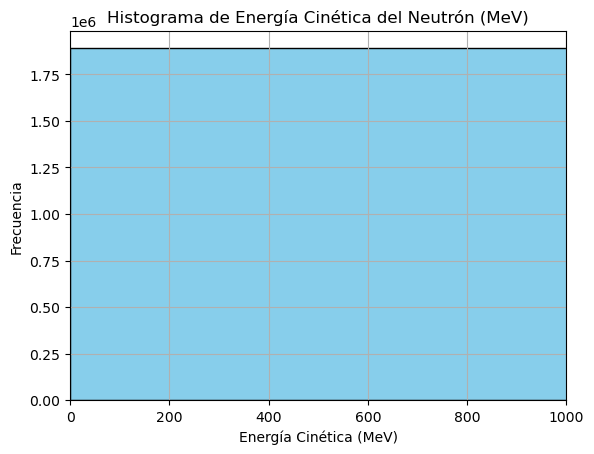

In [15]:
import matplotlib.pyplot as plt
import math

# Constante: masa en reposo del neutrón en MeV
masa_neutron = 939.565  # MeV/c^2

archivo = 'bga_neutron_simulador.txt'
energias_cineticas = []

with open(archivo, 'r') as f:
    for linea in f:
        if linea.strip() == "":
            continue
        partes = linea.strip().split()
        if len(partes) >= 4:
            try:
                # Obtener p_x, p_y, p_z desde las columnas 2, 3 y 4
                px = float(partes[1])
                py = float(partes[2])
                pz = float(partes[3])

                # Calcular p_total
                p_total = math.sqrt(px**2 + py**2 + pz**2)

                # Calcular energía cinética relativista
                energia_total = math.sqrt(p_total**2 + masa_neutron**2)
                energia_cinetica = energia_total - masa_neutron

                energias_cineticas.append(energia_cinetica)
            except ValueError:
                print(f"No se pudo convertir una línea: {linea.strip()}")

# Graficar histograma
plt.hist(energias_cineticas, bins=50, color='skyblue', edgecolor='black')
plt.title('Histograma de Energía Cinética del Neutrón (MeV)')
plt.xlabel('Energía Cinética (MeV)')
plt.xlim(0,1000)
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()


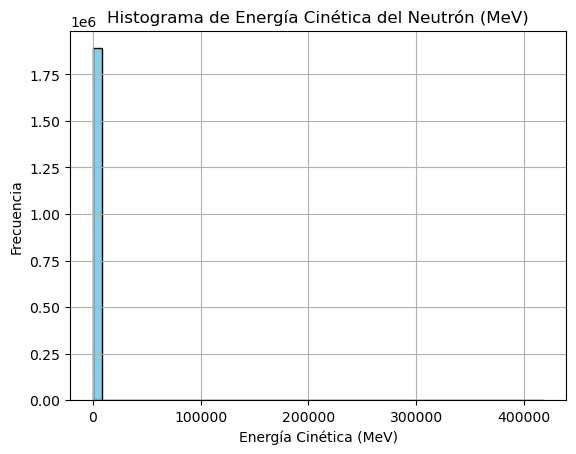

In [17]:
import matplotlib.pyplot as plt
import math

# Constante: masa en reposo del neutrón en MeV
masa_neutron = 939.565  # MeV/c^2

archivo_entrada = 'bga_neutron_simulador.txt'
archivo_salida = 'bga_neutron_simulador_con_energia.txt'

energias_cineticas = []

with open(archivo_entrada, 'r') as fin, open(archivo_salida, 'w') as fout:
    for linea in fin:
        if linea.strip() == "":
            continue
        partes = linea.strip().split()
        if len(partes) >= 4:
            try:
                # Obtener p_x, p_y, p_z desde columnas 2, 3 y 4
                px = float(partes[1])
                py = float(partes[2])
                pz = float(partes[3])

                # Calcular p_total
                p_total = math.sqrt(px**2 + py**2 + pz**2)

                # Calcular energía cinética relativista
                energia_total = math.sqrt(p_total**2 + masa_neutron**2)
                energia_cinetica = energia_total - masa_neutron

                energias_cineticas.append(energia_cinetica)

                # Agregar la energía como nueva columna al final
                nueva_linea = " ".join(partes) + f" {energia_cinetica:.6f}\n"
                fout.write(nueva_linea)

            except ValueError:
                print(f"No se pudo convertir una línea: {linea.strip()}")

# Graficar histograma
plt.hist(energias_cineticas, bins=50, color='skyblue', edgecolor='black')
plt.title('Histograma de Energía Cinética del Neutrón (MeV)')
plt.xlabel('Energía Cinética (MeV)')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()


In [37]:
import math

# Masa en reposo del neutrón en MeV/c^2
masa_neutron = 939.565

archivo_entrada = 'bga_neutron_simulador.txt'
archivo_salida_energia = 'Energias_neutrones.txt'

with open(archivo_entrada, 'r') as fin, open(archivo_salida_energia, 'w') as fout:
    for linea in fin:
        if linea.strip() == "":
            continue
        partes = linea.strip().split()
        if len(partes) >= 4:
            try:
                # Obtener p_x, p_y, p_z desde columnas 2, 3 y 4
                px = float(partes[1])
                py = float(partes[2])
                pz = float(partes[3])

                # Calcular momento total
                p_total = math.sqrt(px**2 + py**2 + pz**2)

                # Energía cinética clásica
                energia_cinetica = (p_total ** 2) / (2 * masa_neutron)

                # Guardar solo la energía en una nueva línea
                fout.write(f"{energia_cinetica:.9f}\n")

            except ValueError:
                print(f"Línea inválida: {linea.strip()}")


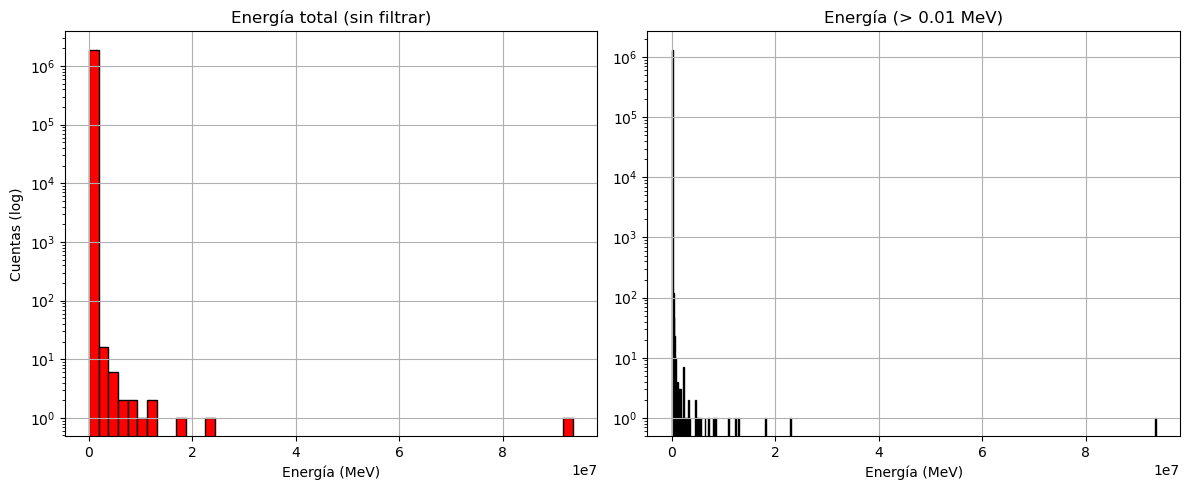

In [45]:
import matplotlib.pyplot as plt

# Leer datos
data = []
with open('Energias_neutrones.txt', 'r') as archivo:
    for linea in archivo:
        try:
            energia = float(linea.strip())
            data.append(energia)
        except ValueError:
            continue

# Histograma original
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(data, bins=50, color='red', edgecolor='black', log=True)
plt.title('Energía total (sin filtrar)')
plt.xlabel('Energía (MeV)')
plt.ylabel('Cuentas (log)')
plt.grid(True)

# Histograma con datos filtrados (>0.01 MeV)
data_filtrada = [x for x in data if x > 0.01]

plt.subplot(1, 2, 2)
plt.hist(data_filtrada, bins=500, color='green', edgecolor='black', log=True)
plt.title('Energía (> 0.01 MeV)')
plt.xlabel('Energía (MeV)')
plt.grid(True)

plt.tight_layout()
plt.savefig('Histograma_doble.png', dpi=300)
plt.show()


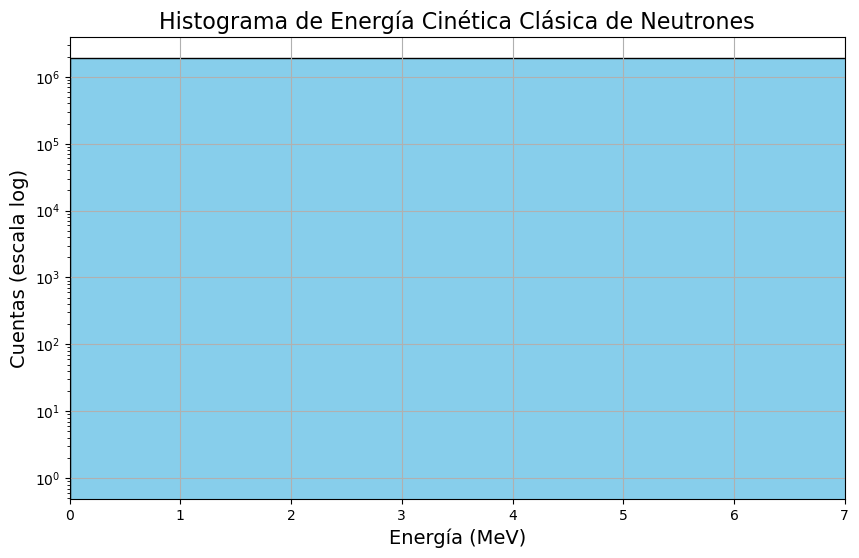

In [35]:
import matplotlib.pyplot as plt
import math

# Leer los datos
data = []
with open('Energias_neutrones.txt', 'r') as archivo:
    for linea in archivo:
        try:
            energia = float(linea.strip())
            data.append(energia)
        except ValueError:
            continue

# Histograma con menos bins
plt.figure(figsize=(10, 6))
plt.hist(data, bins=100, color='skyblue', edgecolor='black', log=True)

plt.xlabel('Energía (MeV)', fontsize=14)
plt.ylabel('Cuentas (escala log)', fontsize=14)
plt.title('Histograma de Energía Cinética Clásica de Neutrones', fontsize=16)
plt.grid(True)

# Ajustar límites para ver mejor
plt.xlim(0, 7)  # o ajusta según lo que veas en tus datos

# Guardar y mostrar
plt.savefig('Histograma_Energia.png', dpi=300)
plt.show()


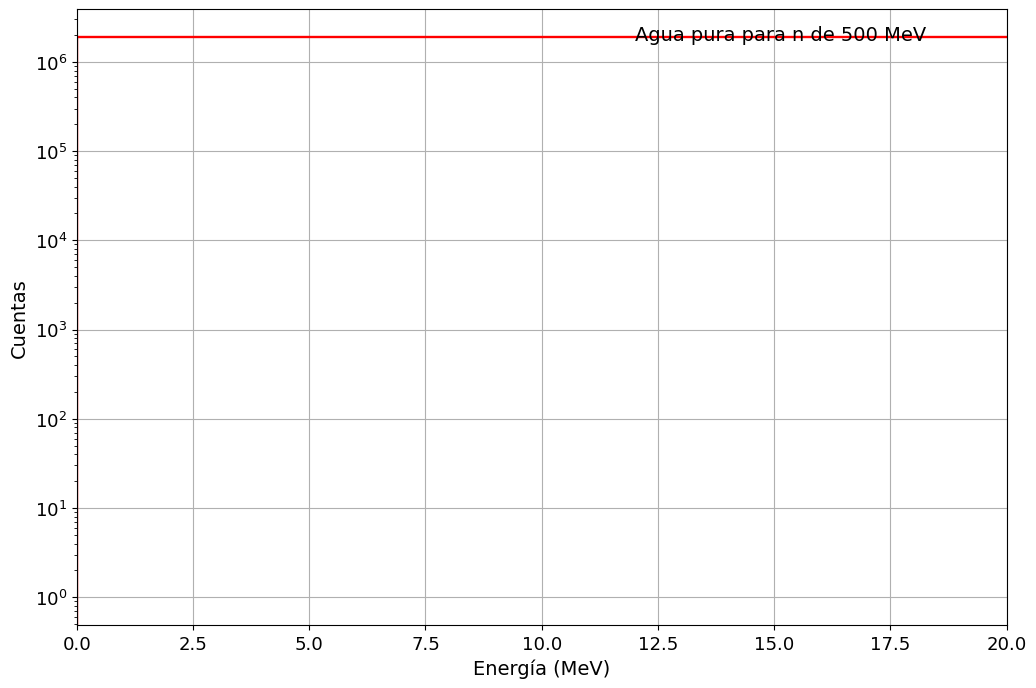

In [33]:
import matplotlib.pyplot as plt
import math
import numpy as np

# Leer archivo de energías
with open('Energias_neutrones.txt', 'r') as archivo:
    data = []
    for linea in archivo:
        columnas = linea.strip().split()
        if columnas:
            try:
                energia = float(columnas[0])
                data.append(energia)
            except ValueError:
                print(f"Línea inválida: {linea.strip()}")

# Calcular número de bins adecuado
num_bins = int(math.sqrt(len(data)))

plt.figure(figsize=(12, 8))

# Histograma con escala logarítmica en Y
counts, bins, _ = plt.hist(data, bins=500, histtype='step', color='red', linewidth=1.7, log=True)

# Puntos centrales
bin_centers = 0.5 * (bins[:-1] + bins[1:])
plt.plot(bin_centers, counts, marker='.', linestyle='-', markersize=4, color='red')

# Texto descriptivo
stats_text = f'Agua pura para n de 500 MeV'
plt.text(0.60, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=14)

# Configuración del gráfico
plt.xlim(0, 20)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel('Energía (MeV)', fontsize=14)
plt.ylabel('Cuentas', fontsize=14)
plt.grid(True)

# Guardar
plt.savefig('Espectro-neutrones.pdf', format='pdf')
plt.savefig('Espectro-neutrones.jpg', format='jpg')

plt.show()


In [3]:
# Abrir el archivo de entrada y salida
with open("flujo-neutrones.txt", "r") as infile, open("neutrones-termicos-1h.txt", "w") as outfile:
    for line in infile:
        data = line.split()  # Separar los valores por espacios
        if len(data) >= 4 and data[0] == "neutron":  # Asegurar que la línea es válida
            col4 = float(data[4])  # Convertir la cuarta columna a número
            if col4 < 0:  # Verificar si la cuarta columna es negativa
                new_line = f"13 {data[1]} {data[2]} {abs(col4)} " + "0 " * 7 + "\n"
                outfile.write(new_line)  # Guardar la línea modificada


In [3]:
# Nombre de los archivos
archivo_entrada = "bga_neutron.txt"
archivo_salida = "bga_neutron_modificado.txt"

# Abrir el archivo de salida en modo escritura
with open(archivo_salida, "w") as salida:
    # Leer el archivo de entrada línea por línea
    with open(archivo_entrada, "r") as entrada:
        for linea in entrada:
            columnas = linea.split()  # Dividir la línea en columnas
            if len(columnas) >= 4:  # Asegurar que tenga al menos 4 columnas
                nueva_linea = f"13 {columnas[1]} {columnas[2]} {columnas[3]} " + "0 " * 8
                salida.write(nueva_linea.strip() + "\n")  # Guardar en el archivo

print(f"Archivo '{archivo_salida}' generado correctamente.")


Archivo 'bga_neutron_modificado.txt' generado correctamente.


In [1]:
# Nombre del archivo de entrada
input_file = "flujo-neutrones.txt"  # Cambia esto por el nombre correcto de tu archivo

# Nombre del archivo de salida
output_file = "flujo-neutrones-1h.txt"

# Abrir los archivos
with open(input_file, 'r') as infile, open(output_file, 'w') as outfile:
    for line in infile:
        columns = line.split()  # Separar la línea en columnas
        
        if len(columns) >= 11:  # Verificar que tenga al menos 11 columnas
            columns[0] = "13"  # Cambiar la columna 1 por 13
            columns[4] = "0"   # Cambiar la columna 5 por 0
            columns[5] = "0"   # Cambiar la columna 6 por 0
            columns[6] = "0"   # Cambiar la columna 7 por 0
            
            # Escribir la línea modificada en el archivo de salida
            outfile.write(" ".join(columns) + "\n")

print(f"El archivo modificado ha sido guardado en '{output_file}'.")


El archivo modificado ha sido guardado en 'flujo-neutrones-1h.txt'.


In [3]:
import math

# Nombre del archivo de entrada
input_file = "flujo-neutrones-1h.txt"  # Cambia esto por el nombre correcto de tu archivo

# Nombre del archivo de salida
output_file = "flujo-neutrones-1h.txt"

# Abrir los archivos
with open(input_file, 'r') as infile, open(output_file, 'w') as outfile:
    for line in infile:
        columns = line.split()  # Separar la línea en columnas
        
        if len(columns) >= 12:  # Verificar que tenga al menos 12 columnas
            try:
                # Convertir las columnas 2, 3 y 4 a float
                x = float(columns[1])
                y = float(columns[2])
                z = float(columns[3])

                # Calcular la magnitud
                magnitude = math.sqrt(x**2 + y**2 + z**2)

                # Agregar el resultado como nueva columna 13
                columns.append(f"{magnitude:.6f}")  # Formatear a 6 decimales

                # Escribir la línea modificada en el archivo de salida
                outfile.write(" ".join(columns) + "\n")
            
            except ValueError:
                print(f"Error procesando la línea: {line.strip()}")

print(f"El archivo modificado ha sido guardado en '{output_file}'.")


El archivo modificado ha sido guardado en 'bga_neutron_modificado_energia.txt'.


In [5]:
# Nombre del archivo de entrada
input_file = "flujo-neutrones-1h-energia.txt"  # Cambia esto por el nombre correcto de tu archivo

# Nombre del archivo de salida
output_file = "flujo-neutrones-1h-baja-energia.txt"

# Abrir los archivos
with open(input_file, 'r') as infile, open(output_file, 'w') as outfile:
    for line in infile:
        columns = line.split()  # Separar la línea en columnas
        
        if len(columns) >= 13:  # Verificar que tenga al menos 13 columnas
            try:
                col_13 = float(columns[12])  # Convertir la columna 13 a número
                
                if col_13 < 0.009:  # Filtrar según la condición
                    outfile.write(line)  # Guardar la línea en el archivo de salida
            
            except ValueError:
                print(f"Error procesando la línea: {line.strip()}")

print(f"Las filas filtradas han sido guardadas en '{output_file}'.")


Las filas filtradas han sido guardadas en 'flujo-neutrones-1h-baja-energia.txt'.


In [23]:
import math

# Nombre del archivo de entrada
input_file = "bga_neutron_modificado.txt"  # Cambia esto por el nombre de tu archivo

# Nombre del archivo de salida
output_file = "bga_neutron_modificado_K.txt"

# Masa del neutrón en MeV/c^2
m_n = 939.565

# Abrir archivos
with open(input_file, 'r') as infile, open(output_file, 'w') as outfile:
    for line in infile:
        columns = line.split()  # Separar la línea en columnas
        
        if len(columns) >= 11:  # Verificar que haya al menos 13 columnas
            try:
                px = float(columns[1])  # Componente x del momento
                py = float(columns[2])  # Componente y del momento
                pz = float(columns[3])  # Componente z del momento
                
                # Filtrar solo las líneas con pz > 0
                if pz > 0:
                    # Calcular la energía cinética
                    B = math.sqrt(px**2 + py**2 + pz**2)  # Magnitud del momento
                    ke = (math.sqrt(p_total**2+m_n**2) - m_n)*1000000  # Energía cinética
                    
                    # Escribir la línea original más la energía cinética
                    outfile.write(line.strip() + f" {ke:.6f}\n")  
            
            except ValueError:
                print(f"Error procesando la línea: {line.strip()}")

print(f"Las filas filtradas han sido guardadas en '{output_file}'.")


Las filas filtradas han sido guardadas en 'bga_neutron_modificado_K.txt'.


In [25]:
# Nombre del archivo de entrada y salida
input_file = "bga_neutron_modificado_K.txt"  # Reemplázalo con el nombre de tu archivo de entrada
output_file = "bga_neutron_termico.txt"

# Abrir archivo de entrada y salida
with open(input_file, "r") as infile, open(output_file, "w") as outfile:
    for line in infile:
        columns = line.split()  # Separar por espacios
        if len(columns) >= 13:  # Asegurar que tiene suficientes columnas
            try:
                col_13_value = float(columns[12])  # Convertir la columna 13 a número
                if col_13_value < 1:
                    outfile.write(line)  # Guardar línea si cumple la condición
            except ValueError:
                continue  # Ignorar líneas con errores de conversión

print(f"Proceso completado. Datos filtrados guardados en '{output_file}'.")


Proceso completado. Datos filtrados guardados en 'bga_neutron_termico.txt'.


In [29]:
import numpy as np

# Nombre del archivo de entrada y salida
input_file = "bga_neutron_modificado.txt"   # Reemplázalo con el nombre de tu archivo de entrada
output_file = "bga_neutron_modificado_Energias.txt"

# Masa en reposo del neutrón en MeV
m0_c2 = 939.565  

# Abrir archivo de entrada y salida
with open(input_file, "r") as infile, open(output_file, "w") as outfile:
    for line in infile:
        columns = line.split()  # Separar por espacios
        if len(columns) >= 4:  # Verificar que tenga suficientes columnas
            try:
                pz = float(columns[3])  # Columna 4 (pz)
                if pz > 0:  # Filtrar filas con pz > 0
                    px = float(columns[1])* 1000  # px en GeV/c
                    py = float(columns[2])* 1000  # py en GeV/c
                    pz = pz*1000  # pz en GeV/c

                    # Calcular la energía cinética
                    p_total = np.sqrt(px**2 + py**2 + pz**2)  # Magnitud del momento
                    E_total = np.sqrt(p_total**2 + (m0_c2)**2)  # Energía total en GeV
                    T = (E_total) - m0_c2  # Energía cinética en MeV

                    # Escribir resultado en archivo
                    outfile.write(f"{T:.4f}\n")
            except ValueError:
                continue  # Ignorar líneas con errores de conversión

print(f"Proceso completado. Resultados guardados en '{output_file}'.")


Proceso completado. Resultados guardados en 'bga_neutron_modificado_Energias.txt'.


In [35]:
import numpy as np

# Archivos de entrada y salida
input_file = "bga_neutron_modificado.txt"        # Reemplaza con el nombre de tu archivo
output_file = "bga_neutron_modificado_Energias.txt"  # Archivo de salida

# Masa en reposo del neutrón en MeV
m0_c2 = 939.565

with open(input_file, "r") as infile, open(output_file, "w") as outfile:
    for line in infile:
        columns = line.strip().split()
        if len(columns) >= 4:
            try:
                pz = float(columns[3])
                if pz > 0:
                    # Convertir px, py, pz a GeV
                    px = float(columns[1]) / 1000
                    py = float(columns[2]) / 1000
                    pz = pz / 1000

                    # Cálculos físicos
                    p_total = np.sqrt(px**2 + py**2 + pz**2)             # Momento total (GeV/c)
                    E_total = np.sqrt(p_total**2 + (m0_c2 / 1000)**2)    # Energía total (GeV)
                    T = (E_total * 1000) - m0_c2                          # Energía cinética (MeV)

                    # Guardar línea original + cálculos
                    resultado = " ".join(columns)
                    resultado += f"  {p_total:.6f}  {E_total:.6f}  {T:.9f}\n"
                    outfile.write(resultado)
            except ValueError:
                continue

print(f"✅ Resultados guardados en '{output_file}'.")


✅ Resultados guardados en 'bga_neutron_modificado_Energias.txt'.


In [39]:
# Archivos de entrada y salida
input_file = "bga_neutron_modificado_Energias.txt"        # Reemplaza con el nombre de tu archivo
output_file = "bga_neutron_Energias_Termico.txt"    # Archivo de salida

with open(input_file, "r") as infile, open(output_file, "w") as outfile:
    for line in infile:
        columns = line.strip().split()
        if len(columns) >= 15:  # Asegurar que haya al menos 15 columnas
            try:
                last_column = float(columns[14])  # Última columna (15)
                if last_column < 0.001:
                    # Convertir px, py, pz (columnas 2, 3, 4) dividiéndolas por 1000
                    columns[1] = f"{float(columns[1]) / 1000:.9f}"
                    columns[2] = f"{float(columns[2]) / 1000:.9f}"
                    columns[3] = f"{float(columns[3]) / 1000:.9f}"

                    # Guardar solo hasta la columna 12
                    outfile.write(" ".join(columns[:12]) + "\n")
            except ValueError:
                continue  # Ignorar líneas con errores de conversión

print(f"✅ Filtrado completado. Datos guardados en '{output_file}'.")


✅ Filtrado completado. Datos guardados en 'bga_neutron_Energias_Termico.txt'.


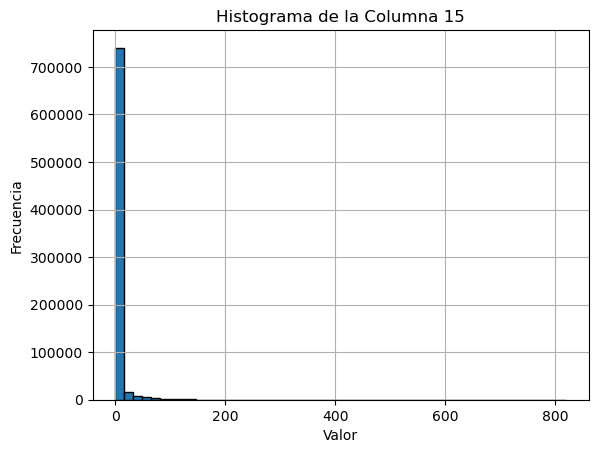

In [3]:
import matplotlib.pyplot as plt

# Ruta del archivo
archivo = 'bga_neutron_modificado_Energias.txt'  # Cambia esto por la ruta de tu archivo

# Lista para almacenar los valores de la columna 15
columna_15 = []

# Leer el archivo línea por línea
with open(archivo, 'r') as f:
    for linea in f:
        if linea.strip() == "":
            continue  # saltar líneas vacías si las hay
        partes = linea.strip().split()
        if len(partes) >= 15:
            try:
                valor = float(partes[14])  # Índice 14 = columna 15
                columna_15.append(valor)
            except ValueError:
                print(f"No se pudo convertir a float: {partes[14]}")

# Crear histograma
plt.hist(columna_15, bins=50, edgecolor='black')
plt.title('Histograma de la Columna 15')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()
